In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import ResNet50, EfficientNetB0, MobileNetV2, VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             balanced_accuracy_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


2026-03-01 09:59:29.096480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772359169.320149      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772359169.390748      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772359169.946648      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772359169.946695      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772359169.946698      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
=== CIFAR-10 Imbalanced Dataset ===
Train samples: 12406,  Test samples: 2579
  Class  0 (airplane    ):  5000 samples
  Class  1 (automobile  ):  2997 samples
  Class  2 (bird        ):  1796 samples
  Class  3 (cat         ):  1077 samples
  Class  4 (deer        ):   645 samples
  Class  5 (dog         ):   387 samples
  Class  6 (frog        ):   232 samples
  Class  7 (horse       ):   139 samples
  Class  8 (ship        ):    83 samples
  Class  9 (truck       ):    50 samples


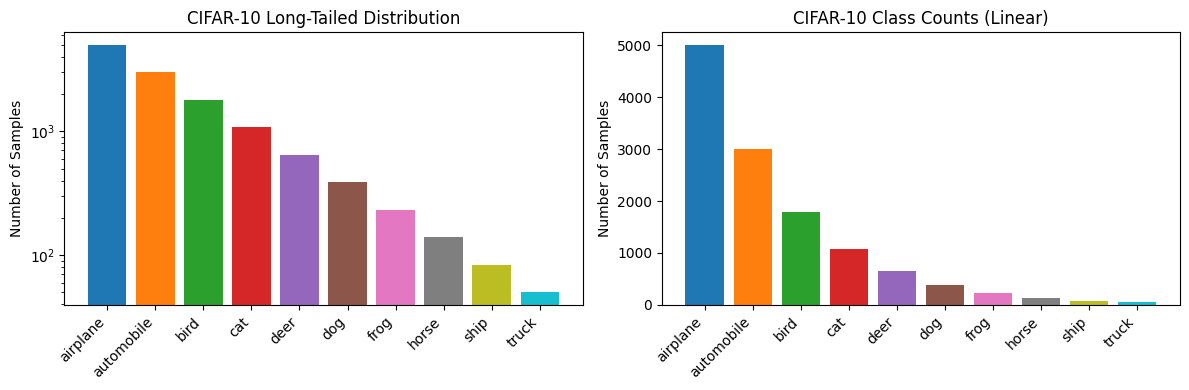

Imbalance Ratio (max/min): 100.0:1


In [2]:
# ─────────────────────────────
# 1A. CIFAR-10 — Create Long-Tailed Imbalanced Distribution (100:1 ratio)
# ─────────────────────────────
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()
y_train_full = y_train_full.flatten()
y_test_full  = y_test_full.flatten()

CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']
NUM_CIFAR = 10

# Long-tailed distribution: class 0 keeps 5000 samples, exponential decay
def create_long_tail(x, y, num_classes=10, max_samples=5000, imbalance_ratio=100):
    """Create long-tailed distribution with given imbalance ratio."""
    selected_x, selected_y = [], []
    samples_per_class = []
    for c in range(num_classes):
        # Exponential decay
        n = int(max_samples * (1/imbalance_ratio) ** (c / (num_classes - 1)))
        n = max(n, 50)  # at least 50 samples
        samples_per_class.append(n)
        idx = np.where(y == c)[0]
        np.random.shuffle(idx)
        chosen = idx[:n]
        selected_x.append(x[chosen])
        selected_y.append(np.full(len(chosen), c))
    x_imb = np.concatenate(selected_x)
    y_imb = np.concatenate(selected_y)
    # Shuffle
    perm = np.random.permutation(len(y_imb))
    return x_imb[perm], y_imb[perm], samples_per_class

x_cifar_train, y_cifar_train, cifar_counts = create_long_tail(x_train_full, y_train_full)
x_cifar_test,  y_cifar_test,  _            = create_long_tail(x_test_full, y_test_full, max_samples=1000)

print("=== CIFAR-10 Imbalanced Dataset ===")
print(f"Train samples: {len(y_cifar_train)},  Test samples: {len(y_cifar_test)}")
for c, n in enumerate(cifar_counts):
    print(f"  Class {c:2d} ({CIFAR_CLASSES[c]:12s}): {n:5d} samples")

# Normalize
x_cifar_train = x_cifar_train.astype('float32') / 255.0
x_cifar_test  = x_cifar_test.astype('float32')  / 255.0

# Plot class distribution
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
bars = plt.bar(CIFAR_CLASSES, cifar_counts, color=plt.cm.tab10(np.arange(10)/10))
plt.xticks(rotation=45, ha='right')
plt.title('CIFAR-10 Long-Tailed Distribution')
plt.ylabel('Number of Samples')
plt.yscale('log')
plt.subplot(1,2,2)
plt.bar(CIFAR_CLASSES, cifar_counts, color=plt.cm.tab10(np.arange(10)/10))
plt.xticks(rotation=45, ha='right')
plt.title('CIFAR-10 Class Counts (Linear)')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig('cifar10_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Imbalance Ratio (max/min): {max(cifar_counts)/min(cifar_counts):.1f}:1")


=== Loading Chest X-Ray Dataset ===
  train/NORMAL: 1341 images
  train/PNEUMONIA: 3875 images
  val/NORMAL: 8 images
  val/PNEUMONIA: 8 images
  test/NORMAL: 234 images
  test/PNEUMONIA: 390 images

Train: (5216, 64, 64, 3), Val: (16, 64, 64, 3), Test: (624, 64, 64, 3)
Class distribution — NORMAL: 1341, PNEUMONIA: 3875
Imbalance Ratio: 2.89:1 (Pneumonia:Normal)


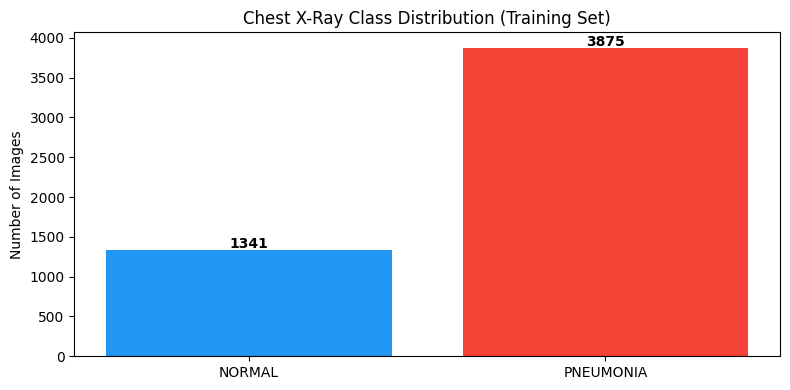

In [6]:
# ─────────────────────────────
# 1B. CHEST X-RAY (Pneumonia) Dataset Loading
# ─────────────────────────────
# ⚠️ Make sure the Chest X-Ray dataset is added to your Kaggle notebook.
# Dataset: paultimothymooney/chest-xray-pneumonia
# After adding, the path will be: /kaggle/input/chest-xray-pneumonia/chest_xray/

CHEST_BASE = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
CHEST_CLASSES = ['NORMAL', 'PNEUMONIA']
IMG_SIZE = (64, 64)  # Use 64x64 for faster training; change to (224,224) for transfer learning

def load_chest_data(base_path, split, img_size=IMG_SIZE):
    """Load Chest X-Ray images into numpy arrays."""
    images, labels = [], []
    split_path = os.path.join(base_path, split)
    for label_idx, cls in enumerate(CHEST_CLASSES):
        cls_path = os.path.join(split_path, cls)
        if not os.path.exists(cls_path):
            print(f"WARNING: {cls_path} not found!")
            continue
        files = os.listdir(cls_path)
        print(f"  {split}/{cls}: {len(files)} images")
        for fname in files:
            if fname.lower().endswith(('.jpeg', '.jpg', '.png')):
                fpath = os.path.join(cls_path, fname)
                img = tf.keras.preprocessing.image.load_img(
                    fpath, color_mode='rgb', target_size=img_size)
                images.append(tf.keras.preprocessing.image.img_to_array(img))
                labels.append(label_idx)
    return np.array(images, dtype='float32') / 255.0, np.array(labels)

print("=== Loading Chest X-Ray Dataset ===")
x_chest_train, y_chest_train = load_chest_data(CHEST_BASE, 'train')
x_chest_val,   y_chest_val   = load_chest_data(CHEST_BASE, 'val')
x_chest_test,  y_chest_test  = load_chest_data(CHEST_BASE, 'test')

print(f"\nTrain: {x_chest_train.shape}, Val: {x_chest_val.shape}, Test: {x_chest_test.shape}")
chest_counts = [np.sum(y_chest_train==0), np.sum(y_chest_train==1)]
print(f"Class distribution — NORMAL: {chest_counts[0]}, PNEUMONIA: {chest_counts[1]}")
print(f"Imbalance Ratio: {chest_counts[1]/chest_counts[0]:.2f}:1 (Pneumonia:Normal)")

plt.figure(figsize=(8,4))
plt.bar(CHEST_CLASSES, chest_counts, color=['#2196F3','#F44336'])
plt.title('Chest X-Ray Class Distribution (Training Set)')
plt.ylabel('Number of Images')
for i,(c,n) in enumerate(zip(CHEST_CLASSES, chest_counts)):
    plt.text(i, n+20, str(n), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('chest_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# ─────────────────────────────────────────────────────
# FIX: Val set is only 16 images — create a proper one
# from training data (15% split)
# ─────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

x_chest_train, x_chest_val, y_chest_train, y_chest_val = train_test_split(
    x_chest_train, y_chest_train,
    test_size=0.15,
    random_state=SEED,
    stratify=y_chest_train
)

print(f"Updated Train: {x_chest_train.shape}")
print(f"Updated Val:   {x_chest_val.shape}")
print(f"Val class dist — NORMAL: {(y_chest_val==0).sum()}, PNEUMONIA: {(y_chest_val==1).sum()}")

# Define here early so it's available throughout the notebook
def get_class_weights(y, num_classes=None):
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

cw_chest = get_class_weights(y_chest_train)
print(f"Updated Class Weights: {cw_chest}")

Updated Train: (3202, 64, 64, 3)
Updated Val:   (566, 64, 64, 3)
Val class dist — NORMAL: 146, PNEUMONIA: 420
Updated Class Weights: {np.int64(0): np.float64(1.945321992709599), np.int64(1): np.float64(0.6729718369062632)}


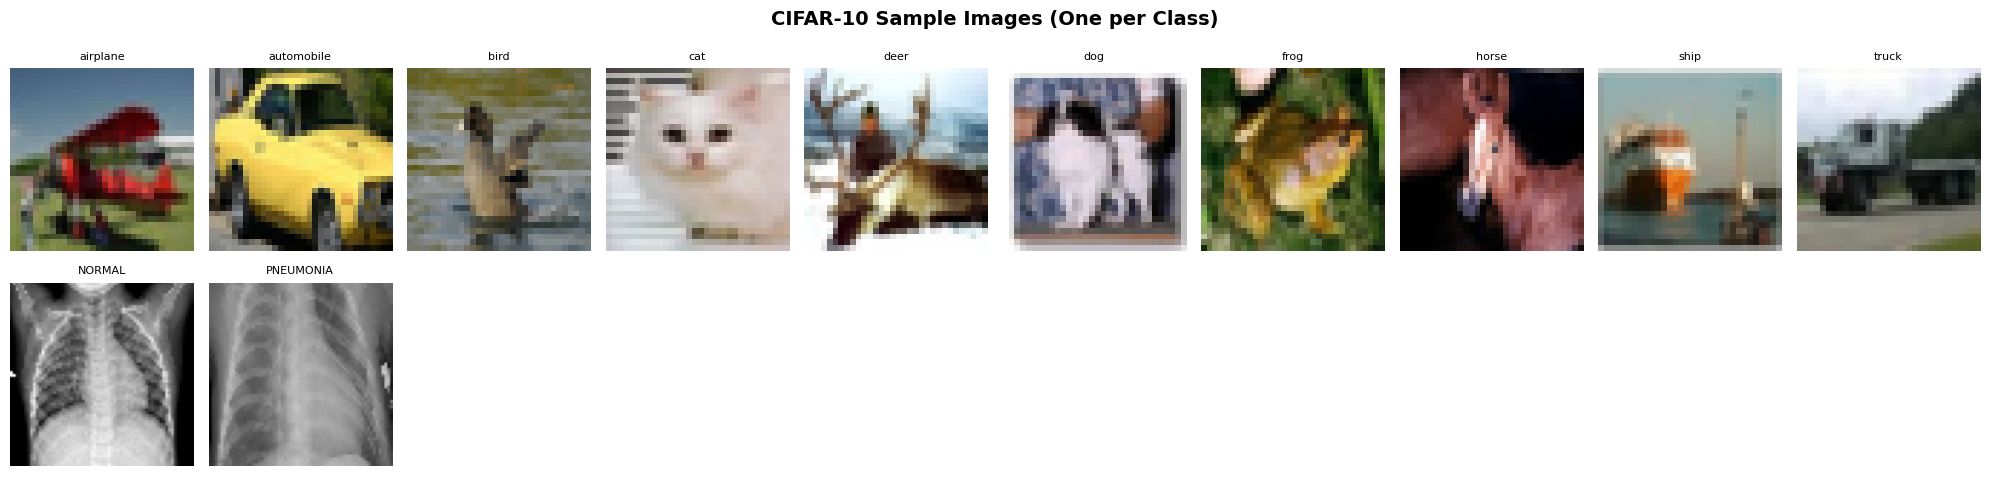

In [10]:
# ─────────────────────────────
# 1C. Visualize Sample Images
# ─────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('CIFAR-10 Sample Images (One per Class)', fontsize=14, fontweight='bold')
for c in range(10):
    idx = np.where(y_cifar_train == c)[0][0]
    axes[0, c].imshow(x_cifar_train[idx])
    axes[0, c].set_title(CIFAR_CLASSES[c], fontsize=8)
    axes[0, c].axis('off')
for c in range(2):
    idx = np.where(y_chest_train == c)[0][0]
    axes[1, c].imshow(x_chest_train[idx], cmap='gray')
    axes[1, c].set_title(CHEST_CLASSES[c], fontsize=8)
    axes[1, c].axis('off')
for c in range(2, 10):
    axes[1, c].axis('off')
axes[1, 0].set_ylabel('Chest X-Ray', fontsize=10)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=120, bbox_inches='tight')
plt.show()


In [11]:
# ════════════════════════════════════════════════════════
# PS1: Custom CNN Architecture with Batch Norm, Dropout, L2
# Justification:
#   - CIFAR-10 (32x32): Lightweight custom CNN - small images don't need deep nets
#   - Chest X-Ray (64x64): Deeper CNN with more filters for medical imaging detail
# ════════════════════════════════════════════════════════

from tensorflow.keras.regularizers import l2

def build_custom_cnn_cifar(num_classes=10, input_shape=(32,32,3)):
    """
    Custom CNN for CIFAR-10 imbalanced classification.
    Architecture justification:
    - 3 conv blocks: sufficient for 32x32 images
    - BatchNorm after each conv: stabilizes training on imbalanced data
    - Dropout: prevents overfitting to majority classes
    - L2 regularization: reduces generalization gap
    """
    inputs = keras.Input(shape=input_shape)
    
    # Block 1: 32 filters, 3x3 kernel
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2: 64 filters, 3x3 kernel
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Block 3: 128 filters, 3x3 kernel
    x = layers.Conv2D(128, (3,3), padding='same', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.4)(x)
    
    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return Model(inputs, outputs, name='CustomCNN_CIFAR10')

def build_custom_cnn_chest(input_shape=(64,64,3)):
    """
    Custom CNN for Chest X-Ray binary classification.
    Deeper architecture for medical images with fine-grained patterns.
    """
    inputs = keras.Input(shape=input_shape)
    
    # Block 1
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 3
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2,2)(x)
    x = layers.Dropout(0.4)(x)
    
    # Block 4
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    return Model(inputs, outputs, name='CustomCNN_ChestXRay')

# Build and summarize
model_cifar = build_custom_cnn_cifar()
model_chest = build_custom_cnn_chest()

print("=" * 60)
print("CIFAR-10 Custom CNN Architecture:")
model_cifar.summary()
print("\n" + "=" * 60)
print("Chest X-Ray Custom CNN Architecture:")
model_chest.summary()

total_params_cifar = model_cifar.count_params()
total_params_chest = model_chest.count_params()
print(f"\nCIFAR-10 model params: {total_params_cifar:,}")
print(f"Chest X-Ray model params: {total_params_chest:,}")


I0000 00:00:1772359925.149754      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772359925.155649      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CIFAR-10 Custom CNN Architecture:


Model: "CustomCNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 176,298 (688.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 651,041 (2.48 MB)

 Trainable params: 649,633 (2.48 MB)

 Non-trainable params: 1,408 (5.50 KB)


CIFAR-10 model params: 176,298
Chest X-Ray model params: 651,041


Training CIFAR-10 Baseline CNN...
Epoch 1/20


I0000 00:00:1772359951.792074     156 service.cc:152] XLA service 0x7c6694006140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772359951.792114     156 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772359951.792119     156 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772359952.621204     156 cuda_dnn.cc:529] Loaded cuDNN version 91002


 15/175 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3518 - loss: 2.0915

I0000 00:00:1772359960.057338     156 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 60ms/step - accuracy: 0.5338 - loss: 1.4546 - val_accuracy: 0.3960 - val_loss: 2.7945 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6623 - loss: 1.0460 - val_accuracy: 0.4290 - val_loss: 2.1156 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6808 - loss: 0.9617 - val_accuracy: 0.5903 - val_loss: 1.2376 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7017 - loss: 0.9011 - val_accuracy: 0.6468 - val_loss: 1.0792 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7137 - loss: 0.8675 - val_accuracy: 0.6000 - val_loss: 1.2093 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7246 - loss: 0.8420 - val_accuracy: 0.5758 - val_loss: 1.2566 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7336 - loss: 0.8085 - val_accur

2026-03-01 10:13:27.123573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:13:27.269214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 26s 224ms/step - accuracy: 0.8334 - loss: 0.3947 - val_accuracy: 0.7420 - val_loss: 2.1576 - learning_rate: 0.0010
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9437 - loss: 0.1952 - val_accuracy: 0.7420 - val_loss: 3.1420 - learning_rate: 0.0010
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9569 - loss: 0.1575 - val_accuracy: 0.7420 - val_loss: 3.0994 - learning_rate: 0.0010
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9534 - loss: 0.1523 - val_accuracy: 0.7420 - val_loss: 2.9121 - learning_rate: 0.0010
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9637 - loss: 0.1300 - val_accuracy: 0.7420 - val_loss: 3.2319 - learning_rate: 5.0000e-04
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9731 - loss: 0.1059 - val_accuracy: 0.7420 - val_loss: 3.2953 - learning_rate: 5.0000e-04
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9782 - loss: 0.0869 - val_accu

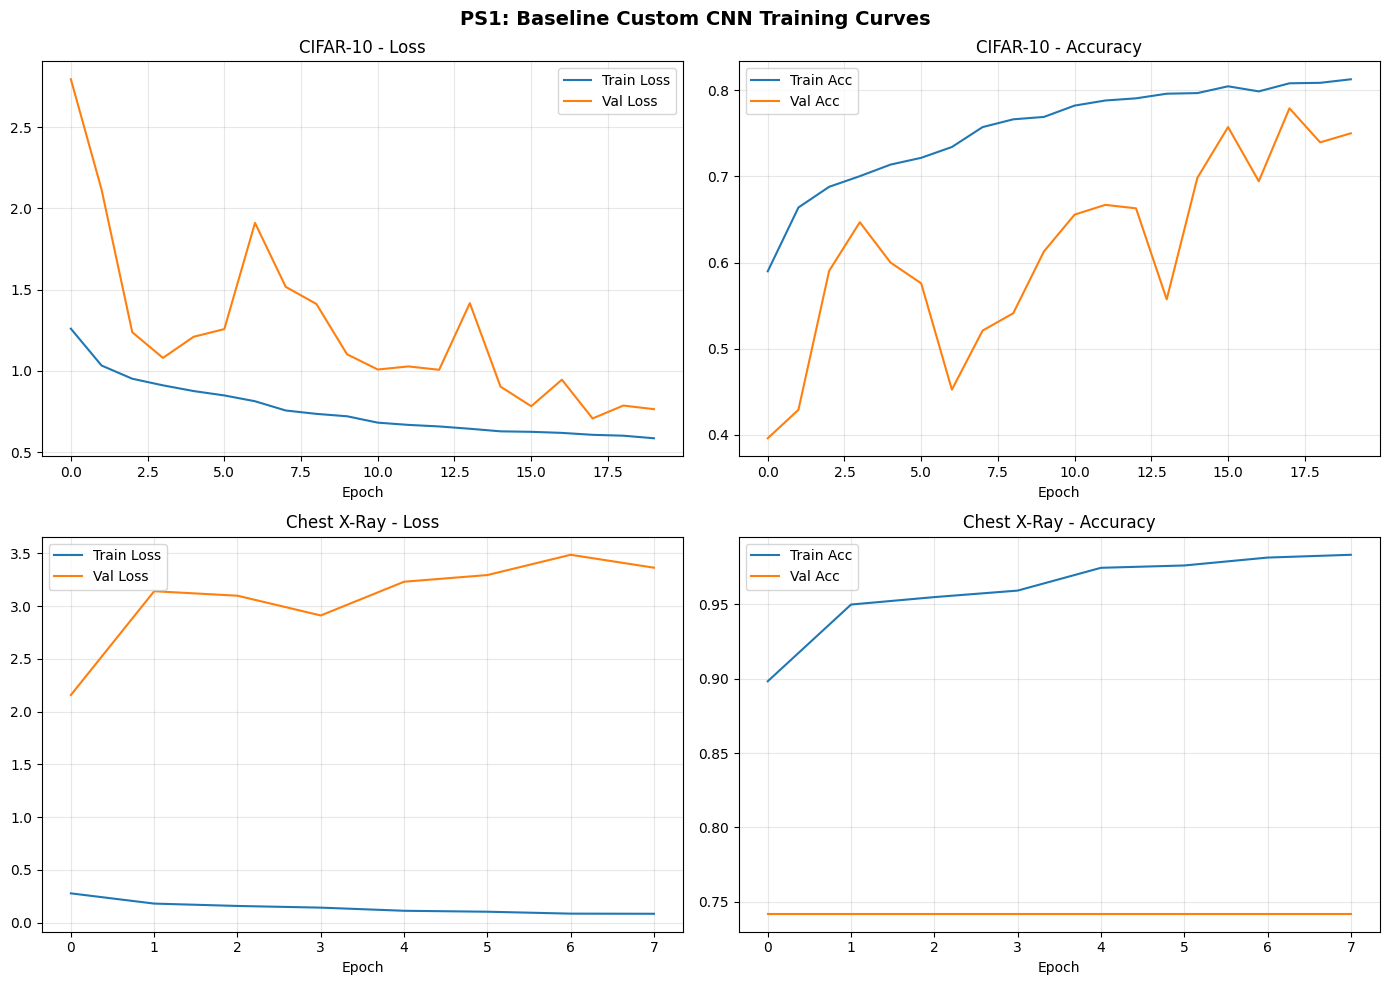


=== CIFAR-10 Baseline Evaluation ===
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
              precision    recall  f1-score   support

    airplane       0.80      0.93      0.86      1000
  automobile       0.94      0.89      0.91       599
        bird       0.66      0.56      0.61       359
         cat       0.40      0.83      0.54       215
        deer       0.62      0.33      0.43       129
         dog       0.50      0.12      0.19        77
        frog       0.64      0.18      0.28        50
       horse       1.00      0.04      0.08        50
        ship       0.00      0.00      0.00        50
       truck       0.00      0.00      0.00        50

    accuracy                           0.74      2579
   macro avg       0.56      0.39      0.39      2579
weighted avg       0.73      0.74      0.71      2579


=== Chest X-Ray Baseline Evaluation ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
              precision    recall  f1-score   support

      NORMAL       0.00    

In [12]:
# ─────────────────────────────
# PS1: Train Baseline Custom CNN (No imbalance handling yet)
# ─────────────────────────────

EPOCHS_BASELINE = 20
BATCH_SIZE = 64

callbacks_base = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6, monitor='val_loss')
]

# ── CIFAR-10 baseline training ──
print("Training CIFAR-10 Baseline CNN...")
model_cifar.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Simple train/val split from training data
val_size = int(0.1 * len(y_cifar_train))
x_cv, y_cv = x_cifar_train[:val_size], y_cifar_train[:val_size]
x_ct, y_ct = x_cifar_train[val_size:], y_cifar_train[val_size:]

hist_cifar_base = model_cifar.fit(
    x_ct, y_ct,
    validation_data=(x_cv, y_cv),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_base,
    verbose=1
)

# ── Chest X-Ray baseline training ──
print("\nTraining Chest X-Ray Baseline CNN...")
model_chest.compile(optimizer='adam',
                    loss='binary_crossentropy',
                    metrics=['accuracy'])

hist_chest_base = model_chest.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_base,
    verbose=1
)

# ── Plot training curves ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PS1: Baseline Custom CNN Training Curves', fontsize=14, fontweight='bold')

for row, (hist, name) in enumerate([(hist_cifar_base, 'CIFAR-10'),
                                     (hist_chest_base, 'Chest X-Ray')]):
    axes[row,0].plot(hist.history['loss'], label='Train Loss')
    axes[row,0].plot(hist.history['val_loss'], label='Val Loss')
    axes[row,0].set_title(f'{name} - Loss')
    axes[row,0].set_xlabel('Epoch')
    axes[row,0].legend()
    axes[row,0].grid(True, alpha=0.3)
    
    axes[row,1].plot(hist.history['accuracy'], label='Train Acc')
    axes[row,1].plot(hist.history['val_accuracy'], label='Val Acc')
    axes[row,1].set_title(f'{name} - Accuracy')
    axes[row,1].set_xlabel('Epoch')
    axes[row,1].legend()
    axes[row,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ps1_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Evaluate baseline ──
print("\n=== CIFAR-10 Baseline Evaluation ===")
cifar_base_preds = np.argmax(model_cifar.predict(x_cifar_test), axis=1)
print(classification_report(y_cifar_test, cifar_base_preds, target_names=CIFAR_CLASSES))

print("\n=== Chest X-Ray Baseline Evaluation ===")
chest_base_preds = (model_chest.predict(x_chest_test) > 0.5).astype(int).flatten()
print(classification_report(y_chest_test, chest_base_preds, target_names=CHEST_CLASSES))


In [13]:
# ════════════════════════════════════════════════════════
# PS2: Imbalance Handling Strategies
# ════════════════════════════════════════════════════════

# ── Strategy 1: Compute Class Weights ──
def get_class_weights(y, num_classes=None):
    """Compute class weights inversely proportional to class frequency."""
    classes = np.unique(y)
    weights = compute_class_weight('balanced', classes=classes, y=y)
    return dict(zip(classes, weights))

cw_cifar = get_class_weights(y_ct, NUM_CIFAR)
cw_chest = get_class_weights(y_chest_train, 2)

print("CIFAR-10 Class Weights:")
for c, w in cw_cifar.items():
    print(f"  {CIFAR_CLASSES[c]:12s}: {w:.3f}")
print(f"\nChest X-Ray Class Weights: {cw_chest}")


CIFAR-10 Class Weights:
  airplane    : 0.249
  automobile  : 0.412
  bird        : 0.697
  cat         : 1.141
  deer        : 1.915
  dog         : 3.043
  frog        : 5.583
  horse       : 8.933
  ship        : 14.501
  truck       : 27.234

Chest X-Ray Class Weights: {np.int64(0): np.float64(1.945321992709599), np.int64(1): np.float64(0.6729718369062632)}


In [14]:
# ── Strategy 2: Random Oversampling (minority classes) ──
def random_oversample(x, y, target_count=None):
    """Oversample minority classes to reach target_count per class."""
    classes, counts = np.unique(y, return_counts=True)
    if target_count is None:
        target_count = counts.max()
    xs, ys = [x], [y]
    for c, cnt in zip(classes, counts):
        if cnt < target_count:
            idx = np.where(y == c)[0]
            n_extra = target_count - cnt
            extra_idx = np.random.choice(idx, n_extra, replace=True)
            xs.append(x[extra_idx])
            ys.append(np.full(n_extra, c))
    x_bal = np.concatenate(xs)
    y_bal = np.concatenate(ys)
    perm = np.random.permutation(len(y_bal))
    return x_bal[perm], y_bal[perm]

# Oversample CIFAR-10 (targeting max class count)
x_cifar_os, y_cifar_os = random_oversample(x_ct, y_ct)
print(f"CIFAR-10 After Oversampling: {x_cifar_os.shape}, {np.unique(y_cifar_os, return_counts=True)[1]}")

# Oversample Chest X-Ray
x_chest_os, y_chest_os = random_oversample(x_chest_train, y_chest_train)
print(f"Chest X-Ray After Oversampling: {x_chest_os.shape}, {np.unique(y_chest_os, return_counts=True)[1]}")


CIFAR-10 After Oversampling: (44800, 32, 32, 3), [4480 4480 4480 4480 4480 4480 4480 4480 4480 4480]
Chest X-Ray After Oversampling: (4758, 64, 64, 3), [2379 2379]


In [15]:
# ── Strategy 3: Augmentation for Minority Classes ──
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment_minority_classes(x, y, augmentation_factor=3, minority_threshold=None):
    """Apply data augmentation specifically to minority classes."""
    classes, counts = np.unique(y, return_counts=True)
    if minority_threshold is None:
        minority_threshold = counts.mean()
    
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.15,
        height_shift_range=0.15,
        horizontal_flip=True,
        zoom_range=0.15,
        shear_range=0.1,
        fill_mode='nearest'
    )
    
    xs, ys = [x], [y]
    for c, cnt in zip(classes, counts):
        if cnt < minority_threshold:
            idx = np.where(y == c)[0]
            imgs = x[idx]
            n_to_gen = int(cnt * augmentation_factor)
            gen = datagen.flow(imgs, batch_size=32, shuffle=True)
            aug_imgs = []
            while len(aug_imgs) < n_to_gen:
                batch = next(gen)
                aug_imgs.extend(batch)
            aug_imgs = np.array(aug_imgs[:n_to_gen])
            xs.append(aug_imgs)
            ys.append(np.full(n_to_gen, c))
    
    x_aug = np.concatenate(xs)
    y_aug = np.concatenate(ys)
    perm = np.random.permutation(len(y_aug))
    return x_aug[perm], y_aug[perm]

print("Applying augmentation to CIFAR-10 minority classes...")
x_cifar_aug, y_cifar_aug = augment_minority_classes(x_ct, y_ct, augmentation_factor=2)
print(f"CIFAR-10 After Augmentation: {x_cifar_aug.shape}")
print(f"Class counts: {np.unique(y_cifar_aug, return_counts=True)[1]}")


Applying augmentation to CIFAR-10 minority classes...
CIFAR-10 After Augmentation: (15910, 32, 32, 3)
Class counts: [4480 2711 1603 2937 1749 1101  600  375  231  123]


In [19]:
# ── Strategy 4 Cell 1: CIFAR-10 Training ──

print("Training CIFAR-10 with Class Weights...")
model_cifar_cw = build_custom_cnn_cifar()
model_cifar_cw.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
hist_cifar_cw = model_cifar_cw.fit(
    x_ct, y_ct,
    validation_data=(x_cv, y_cv),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_SIZE,
    class_weight=cw_cifar,
    callbacks=callbacks_base,
    verbose=1
)
print("✅ CIFAR-10 Class Weights done!")

print("\nTraining CIFAR-10 with Oversampling...")
model_cifar_os = build_custom_cnn_cifar()
model_cifar_os.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
val_os_size = int(0.1 * len(y_cifar_os))
hist_cifar_os = model_cifar_os.fit(
    x_cifar_os[val_os_size:], y_cifar_os[val_os_size:],
    validation_data=(x_cifar_os[:val_os_size], y_cifar_os[:val_os_size]),
    epochs=EPOCHS_BASELINE,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_base,
    verbose=1
)
print("✅ CIFAR-10 Oversampling done!")

Training CIFAR-10 with Class Weights...
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.2067 - loss: 2.2847 - val_accuracy: 0.1750 - val_loss: 2.4201 - learning_rate: 0.0010
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2832 - loss: 1.9300 - val_accuracy: 0.1121 - val_loss: 2.8944 - learning_rate: 0.0010
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3100 - loss: 1.8111 - val_accuracy: 0.1355 - val_loss: 2.3271 - learning_rate: 0.0010
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.3204 - loss: 1.7179 - val_accuracy: 0.1976 - val_loss: 2.0130 - learning_rate: 0.0010
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3438 - loss: 1.6744 - val_accuracy: 0.1331 - val_loss: 2.1176 - learning_rate: 0.0010
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3600 - loss: 1.6367 - val_accuracy: 0.2016 - val_loss: 1.9401 - learning_rate: 0.0010
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms

In [20]:
# ── Strategy 4 Cell 2: Chest X-Ray Training ──

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import gc
gc.collect()

print("Training Chest X-Ray with Class Weights...")
tf.random.set_seed(42)
model_chest_cw = build_custom_cnn_chest()
model_chest_cw.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

callbacks_chest_fixed = [
    tf.keras.callbacks.EarlyStopping(
        patience=8,
        restore_best_weights=True,
        monitor='val_auc',
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        monitor='val_auc',
        mode='max',
        verbose=1
    )
]

datagen_chest = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)

hist_chest_cw = model_chest_cw.fit(
    datagen_chest.flow(x_chest_train, y_chest_train, batch_size=32),
    validation_data=(x_chest_val, y_chest_val),
    epochs=EPOCHS_BASELINE,
    steps_per_epoch=len(x_chest_train) // 32,
    class_weight=cw_chest,
    callbacks=callbacks_chest_fixed,
    verbose=1
)
print("✅ Chest X-Ray done!")

# Sanity check
probs_check = model_chest_cw.predict(x_chest_val[:20]).flatten()
print(f"\nSanity check: {probs_check.round(2)}")
print(f"Min: {probs_check.min():.3f} | Max: {probs_check.max():.3f}")

Training Chest X-Ray with Class Weights...
Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.7761 - auc: 0.8879 - loss: 0.4487 - recall: 0.7290 - val_accuracy: 0.7420 - val_auc: 0.4639 - val_loss: 1.4378 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9062 - auc: 1.0000 - loss: 0.1754 - recall: 0.8846 - val_accuracy: 0.7420 - val_auc: 0.4681 - val_loss: 1.4342 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8687 - auc: 0.9510 - loss: 0.3296 - recall: 0.8470 - val_accuracy: 0.7420 - val_auc: 0.5000 - val_loss: 2.1826 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9375 - auc: 0.9795 - loss: 0.3014 - recall: 1.0000 - val_accuracy: 0.7420 - val_auc: 0.5000 - val_loss: 2.1576 - val_recall: 1.0000 - learning_rate: 3.0000e-04
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/s

=== Threshold Adjustment for Chest X-Ray ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
 Threshold  Accuracy  F1-NORMAL  F1-PNEUMONIA  Macro-F1
       0.3  0.862179   0.788177      0.897862  0.843020
       0.4  0.871795   0.812207      0.902676  0.857441
       0.5  0.878205   0.827273      0.905941  0.866607
       0.6  0.881410   0.836283      0.907035  0.871659
       0.7  0.886218   0.847312      0.909323  0.878317


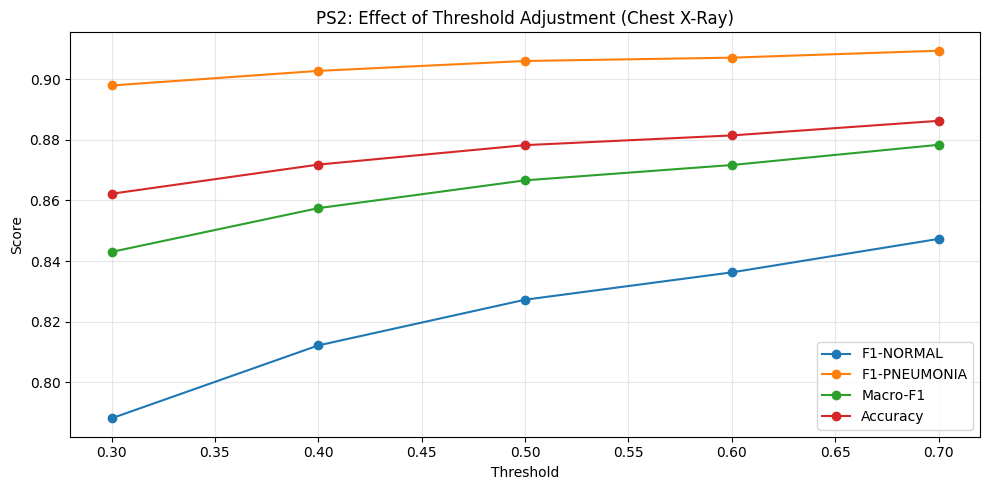

In [21]:
# ── Strategy 5: Threshold Adjustment for Chest X-Ray ──
print("=== Threshold Adjustment for Chest X-Ray ===")
probs_chest = model_chest_cw.predict(x_chest_test).flatten()

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results_thresh = []
for thresh in thresholds:
    preds = (probs_chest > thresh).astype(int)
    report = classification_report(y_chest_test, preds, target_names=CHEST_CLASSES, output_dict=True)
    f1_normal = report['NORMAL']['f1-score']
    f1_pneumo = report['PNEUMONIA']['f1-score']
    macro_f1  = report['macro avg']['f1-score']
    acc       = report['accuracy']
    results_thresh.append({'Threshold':thresh, 'Accuracy':acc,
                           'F1-NORMAL':f1_normal, 'F1-PNEUMONIA':f1_pneumo, 'Macro-F1':macro_f1})
    
df_thresh = pd.DataFrame(results_thresh)
print(df_thresh.to_string(index=False))

plt.figure(figsize=(10,5))
for col in ['F1-NORMAL','F1-PNEUMONIA','Macro-F1','Accuracy']:
    plt.plot(df_thresh['Threshold'], df_thresh[col], marker='o', label=col)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('PS2: Effect of Threshold Adjustment (Chest X-Ray)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ps2_threshold_adjustment.png', dpi=120, bbox_inches='tight')
plt.show()


=== PS2 Comparison: Imbalance Handling Strategies on CIFAR-10 ===
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
     Strategy Accuracy Macro-F1 Micro-F1 Balanced Acc
     Baseline    0.740    0.390    0.740        0.388
Class Weights    0.577    0.440    0.577        0.527
 Oversampling    0.788    0.628    0.788        0.617
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


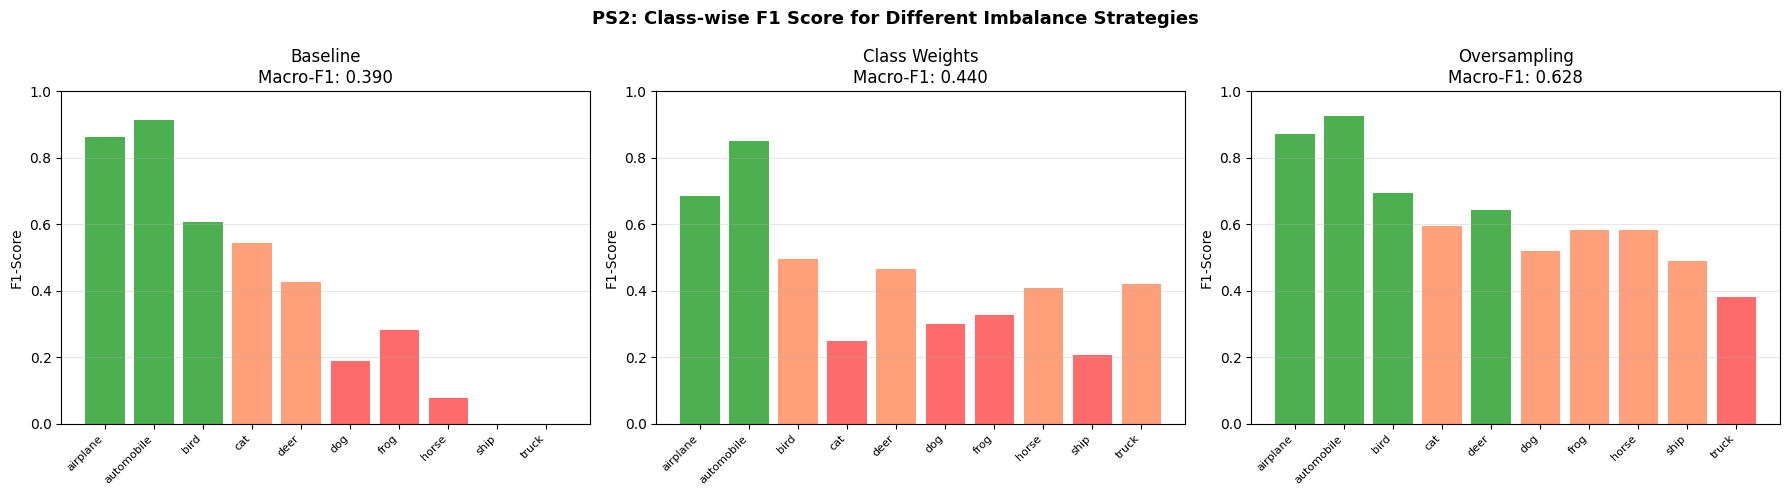

In [22]:
# ── PS2 Summary: Compare all strategies ──
print("=== PS2 Comparison: Imbalance Handling Strategies on CIFAR-10 ===")
strategies = ['Baseline', 'Class Weights', 'Oversampling']
models_ps2 = [model_cifar, model_cifar_cw, model_cifar_os]

results_ps2 = []
for name, mdl in zip(strategies, models_ps2):
    preds = np.argmax(mdl.predict(x_cifar_test), axis=1)
    macro_f1  = f1_score(y_cifar_test, preds, average='macro')
    micro_f1  = f1_score(y_cifar_test, preds, average='micro')
    bal_acc   = balanced_accuracy_score(y_cifar_test, preds)
    acc       = np.mean(preds == y_cifar_test)
    results_ps2.append({'Strategy':name, 'Accuracy':f'{acc:.3f}',
                        'Macro-F1':f'{macro_f1:.3f}', 'Micro-F1':f'{micro_f1:.3f}',
                        'Balanced Acc':f'{bal_acc:.3f}'})
    
df_ps2 = pd.DataFrame(results_ps2)
print(df_ps2.to_string(index=False))

# Visualize class-wise F1 comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PS2: Class-wise F1 Score for Different Imbalance Strategies', fontsize=13, fontweight='bold')
for ax, (name, mdl) in zip(axes, zip(strategies, models_ps2)):
    preds = np.argmax(mdl.predict(x_cifar_test), axis=1)
    report = classification_report(y_cifar_test, preds, target_names=CIFAR_CLASSES, output_dict=True)
    f1s = [report[c]['f1-score'] for c in CIFAR_CLASSES]
    colors = ['#FF6B6B' if f < 0.4 else '#FFA07A' if f < 0.6 else '#4CAF50' for f in f1s]
    ax.bar(CIFAR_CLASSES, f1s, color=colors)
    ax.set_title(f'{name}\nMacro-F1: {f1_score(y_cifar_test, preds, average="macro"):.3f}')
    ax.set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ps2_strategy_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


In [23]:
# ════════════════════════════════════════════════════════
# PS3: Transfer Learning Architectures for Comparison
# Using pre-trained ImageNet weights → Fine-tune on our datasets
# ════════════════════════════════════════════════════════

def build_transfer_model(base_name, num_classes, input_shape, binary=False):
    """Build a transfer learning model with the given backbone."""
    base_builders = {
        'EfficientNetB0': EfficientNetB0,
        'ResNet50':       ResNet50,
        'MobileNetV2':    MobileNetV2,
    }
    assert base_name in base_builders, f"Unknown architecture: {base_name}"
    
    # Resize layer for small inputs (CIFAR-10 = 32x32, needs ≥75 for EfficientNet)
    inputs = keras.Input(shape=input_shape)
    x = layers.Resizing(96, 96)(inputs)  # Upscale to 96x96 for pretrained models
    
    base = base_builders[base_name](
        include_top=False, weights='imagenet', input_tensor=x)
    base.trainable = False  # Feature extraction mode initially
    
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    
    if binary:
        outputs = layers.Dense(1, activation='sigmoid')(x)
        loss = 'binary_crossentropy'
    else:
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        loss = 'sparse_categorical_crossentropy'
    
    model = Model(inputs, outputs, name=base_name)
    return model, loss

ARCH_NAMES = ['EfficientNetB0', 'ResNet50', 'MobileNetV2']
EPOCHS_TRANSFER = 15
BATCH_TRANSFER  = 32

arch_results = {ds: {} for ds in ['CIFAR10', 'ChestXRay']}
arch_histories = {ds: {} for ds in ['CIFAR10', 'ChestXRay']}
arch_models   = {ds: {} for ds in ['CIFAR10', 'ChestXRay']}

for arch in ARCH_NAMES:
    print(f"\n{'='*55}")
    print(f" Architecture: {arch}")
    print('='*55)
    
    # ── CIFAR-10 ──
    print(f"  [CIFAR-10] Building {arch}...")
    mdl_c, loss_c = build_transfer_model(arch, NUM_CIFAR, (32,32,3), binary=False)
    mdl_c.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=loss_c, metrics=['accuracy'])
    t0 = time.time()
    hist_c = mdl_c.fit(x_ct, y_ct,
                       validation_data=(x_cv, y_cv),
                       epochs=EPOCHS_TRANSFER, batch_size=BATCH_TRANSFER,
                       class_weight=cw_cifar,
                       callbacks=callbacks_base, verbose=0)
    t_cifar = time.time() - t0
    preds_c = np.argmax(mdl_c.predict(x_cifar_test), axis=1)
    acc_c   = np.mean(preds_c == y_cifar_test)
    mf1_c   = f1_score(y_cifar_test, preds_c, average='macro')
    ba_c    = balanced_accuracy_score(y_cifar_test, preds_c)
    arch_results['CIFAR10'][arch] = {
        'accuracy': acc_c, 'macro_f1': mf1_c, 'balanced_acc': ba_c,
        'params': mdl_c.count_params(), 'train_time': t_cifar,
        'preds': preds_c, 'report': classification_report(y_cifar_test, preds_c, target_names=CIFAR_CLASSES, output_dict=True)
    }
    arch_histories['CIFAR10'][arch] = hist_c
    arch_models['CIFAR10'][arch] = mdl_c
    print(f"    CIFAR-10  → Acc:{acc_c:.3f} | Macro-F1:{mf1_c:.3f} | BalAcc:{ba_c:.3f} | Time:{t_cifar:.1f}s")
    
    # ── Chest X-Ray ──
    print(f"  [Chest]    Building {arch}...")
    mdl_x, loss_x = build_transfer_model(arch, 2, (64,64,3), binary=True)
    mdl_x.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=loss_x, metrics=['accuracy'])
    t0 = time.time()
    hist_x = mdl_x.fit(x_chest_train, y_chest_train,
                       validation_data=(x_chest_val, y_chest_val),
                       epochs=EPOCHS_TRANSFER, batch_size=BATCH_TRANSFER,
                       class_weight=cw_chest,
                       callbacks=callbacks_base, verbose=0)
    t_chest = time.time() - t0
    preds_x = (mdl_x.predict(x_chest_test) > 0.5).astype(int).flatten()
    acc_x   = np.mean(preds_x == y_chest_test)
    mf1_x   = f1_score(y_chest_test, preds_x, average='macro')
    ba_x    = balanced_accuracy_score(y_chest_test, preds_x)
    arch_results['ChestXRay'][arch] = {
        'accuracy': acc_x, 'macro_f1': mf1_x, 'balanced_acc': ba_x,
        'params': mdl_x.count_params(), 'train_time': t_chest,
        'preds': preds_x, 'probs': mdl_x.predict(x_chest_test).flatten(),
        'report': classification_report(y_chest_test, preds_x, target_names=CHEST_CLASSES, output_dict=True)
    }
    arch_histories['ChestXRay'][arch] = hist_x
    arch_models['ChestXRay'][arch] = mdl_x
    print(f"    Chest     → Acc:{acc_x:.3f} | Macro-F1:{mf1_x:.3f} | BalAcc:{ba_x:.3f} | Time:{t_chest:.1f}s")



 Architecture: EfficientNetB0
  [CIFAR-10] Building EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


2026-03-01 10:35:44.914783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:35:45.048826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:35:45.368428: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:35:45.510104: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:35:46.263820: E external/local_xla/xla/stream_

75/81 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

2026-03-01 10:37:39.459805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:37:39.593631: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:37:39.913860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:37:40.055572: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:37:40.785422: E external/local_xla/xla/stream_

81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step
    CIFAR-10  → Acc:0.019 | Macro-F1:0.004 | BalAcc:0.100 | Time:118.4s
  [Chest]    Building EfficientNetB0...


...

81/81 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step
    CIFAR-10  → Acc:0.781 | Macro-F1:0.651 | BalAcc:0.660 | Time:80.3s
  [Chest]    Building MobileNetV2...


2026-03-01 10:44:55.290703: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:44:55.441007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:44:55.577959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:45:07.807136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:45:07.944059: E external/local_xla/xla/stream_

16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

2026-03-01 10:45:36.247210: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:45:36.394511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 10:45:36.531225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 458ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
    Chest     → Acc:0.821 | Macro-F1:0.784 | BalAcc:0.765 | Time:46.7s


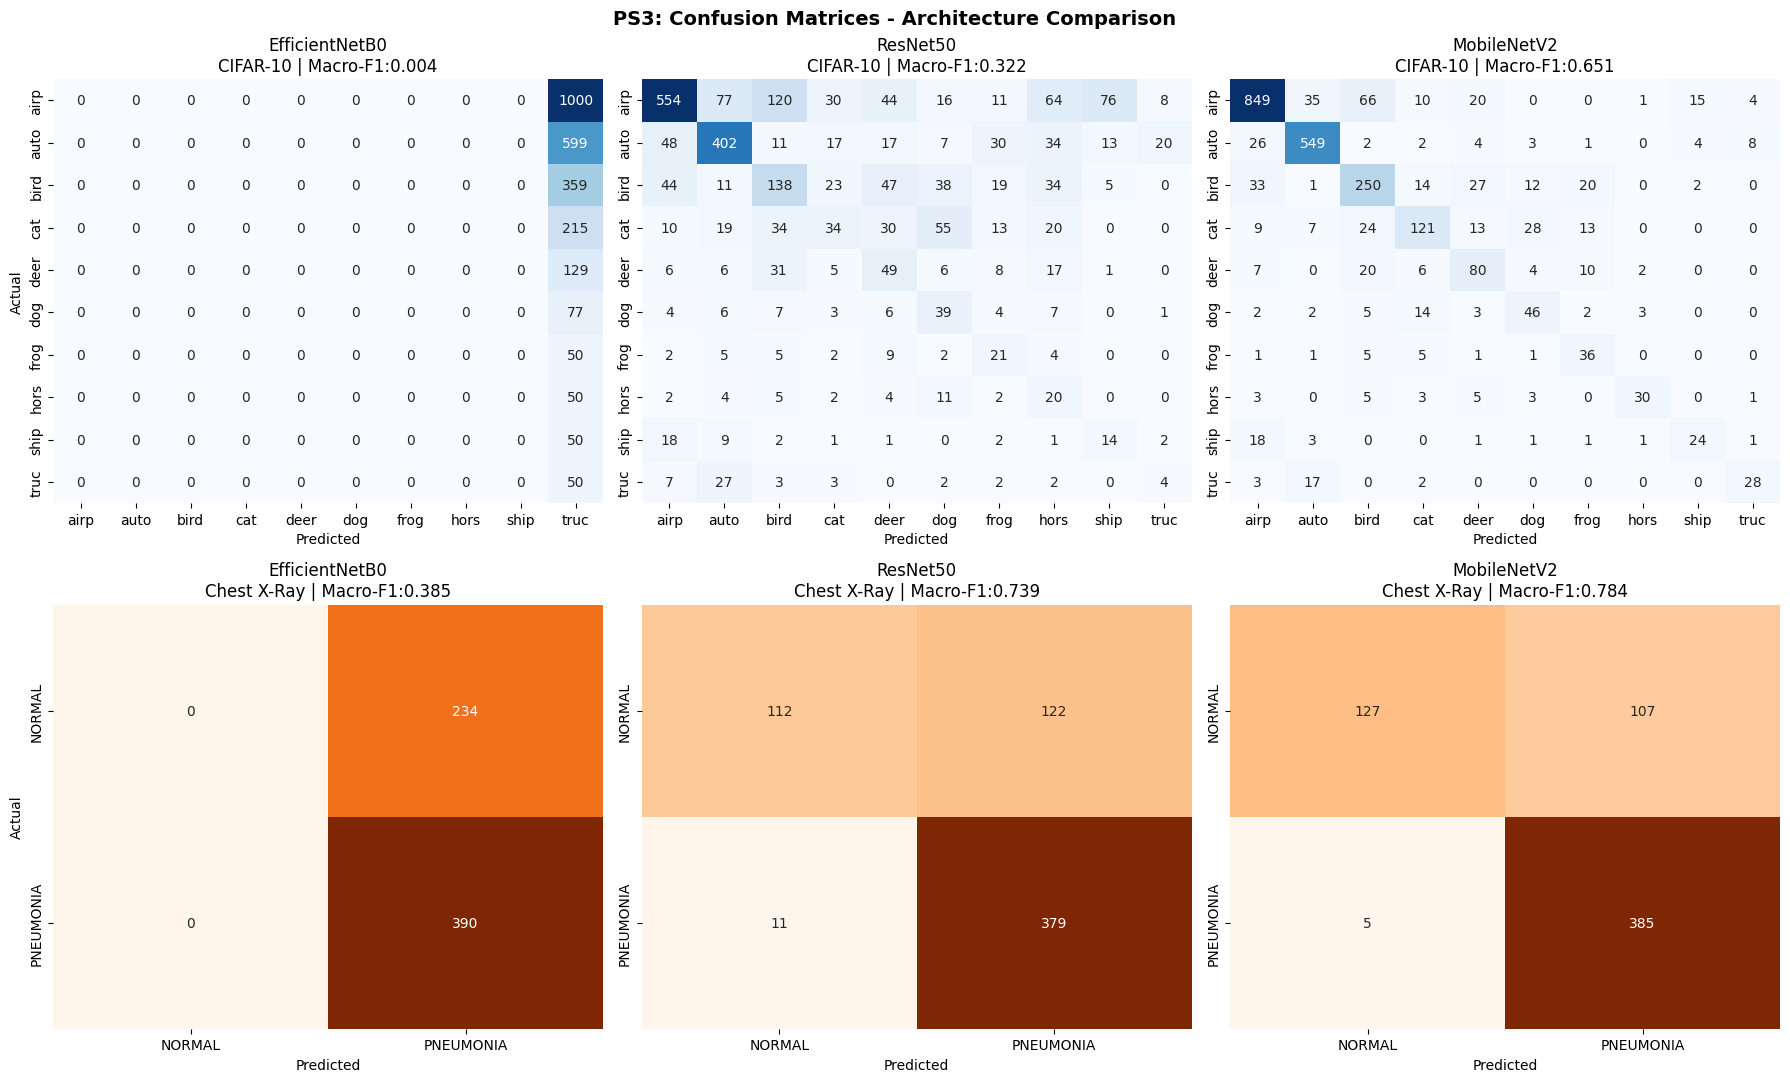

In [24]:
# ── PS3: Confusion Matrices ──
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('PS3: Confusion Matrices - Architecture Comparison', fontsize=14, fontweight='bold')

for col, arch in enumerate(ARCH_NAMES):
    # CIFAR-10
    preds_c = arch_results['CIFAR10'][arch]['preds']
    cm_c = confusion_matrix(y_cifar_test, preds_c)
    sns.heatmap(cm_c, annot=True, fmt='d', ax=axes[0,col],
                xticklabels=[c[:4] for c in CIFAR_CLASSES],
                yticklabels=[c[:4] for c in CIFAR_CLASSES],
                cmap='Blues', cbar=False)
    axes[0,col].set_title(f'{arch}\nCIFAR-10 | Macro-F1:{arch_results["CIFAR10"][arch]["macro_f1"]:.3f}')
    axes[0,col].set_xlabel('Predicted')
    if col == 0: axes[0,col].set_ylabel('Actual')
    
    # Chest X-Ray
    preds_x = arch_results['ChestXRay'][arch]['preds']
    cm_x = confusion_matrix(y_chest_test, preds_x)
    sns.heatmap(cm_x, annot=True, fmt='d', ax=axes[1,col],
                xticklabels=CHEST_CLASSES, yticklabels=CHEST_CLASSES,
                cmap='Oranges', cbar=False)
    axes[1,col].set_title(f'{arch}\nChest X-Ray | Macro-F1:{arch_results["ChestXRay"][arch]["macro_f1"]:.3f}')
    axes[1,col].set_xlabel('Predicted')
    if col == 0: axes[1,col].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('ps3_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()


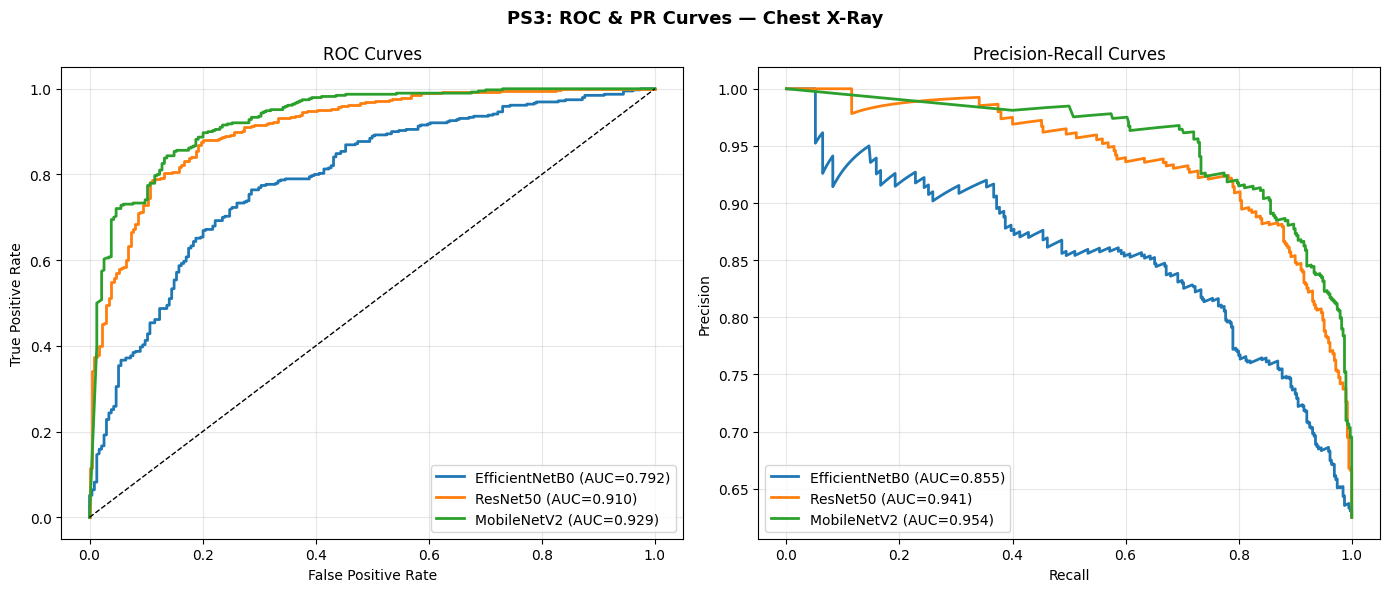

=== PS3: Architecture Comparison Summary ===
  Architecture   Dataset Accuracy Macro-F1 Balanced Acc Params (M) Train Time (s) ROC-AUC PR-AUC
EfficientNetB0  CIFAR-10    0.019    0.004        0.100       4.39          118.4     NaN    NaN
EfficientNetB0 ChestXRay    0.625    0.385        0.500       4.38           65.3   0.792  0.855
      ResNet50  CIFAR-10    0.494    0.322        0.383      24.12          146.6     NaN    NaN
      ResNet50 ChestXRay    0.787    0.739        0.725      24.12           63.9   0.910  0.941
   MobileNetV2  CIFAR-10    0.781    0.651        0.660       2.59           80.3     NaN    NaN
   MobileNetV2 ChestXRay    0.821    0.784        0.765       2.59           46.7   0.929  0.954


In [25]:
# ── PS3: ROC-AUC & PR-AUC for Chest X-Ray ──
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('PS3: ROC & PR Curves — Chest X-Ray', fontsize=13, fontweight='bold')
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for color, arch in zip(colors, ARCH_NAMES):
    probs = arch_results['ChestXRay'][arch]['probs']
    # ROC
    fpr, tpr, _ = roc_curve(y_chest_test, probs)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, label=f'{arch} (AUC={roc_auc:.3f})', lw=2)
    # PR
    prec, rec, _ = precision_recall_curve(y_chest_test, probs)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, label=f'{arch} (AUC={pr_auc:.3f})', lw=2)
    arch_results['ChestXRay'][arch]['roc_auc'] = roc_auc
    arch_results['ChestXRay'][arch]['pr_auc']  = pr_auc

axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ps3_roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# ── PS3: Summary Table ──
print("=== PS3: Architecture Comparison Summary ===")
rows = []
for arch in ARCH_NAMES:
    for ds, res in [('CIFAR-10', arch_results['CIFAR10'][arch]),
                    ('ChestXRay', arch_results['ChestXRay'][arch])]:
        row = {'Architecture': arch, 'Dataset': ds,
               'Accuracy': f"{res['accuracy']:.3f}",
               'Macro-F1': f"{res['macro_f1']:.3f}",
               'Balanced Acc': f"{res['balanced_acc']:.3f}",
               'Params (M)': f"{res['params']/1e6:.2f}",
               'Train Time (s)': f"{res['train_time']:.1f}"}
        if 'roc_auc' in res:
            row['ROC-AUC'] = f"{res['roc_auc']:.3f}"
            row['PR-AUC']  = f"{res['pr_auc']:.3f}"
        rows.append(row)
df_ps3 = pd.DataFrame(rows)
print(df_ps3.to_string(index=False))


In [29]:
# ════════════════════════════════════════════════════════
# PS4: Custom Loss Functions
# ════════════════════════════════════════════════════════

# ── Focal Loss ──
def focal_loss(gamma=2.0, alpha=0.25):
    """
    Focal Loss: FL(p) = -alpha*(1-p)^gamma * log(p)
    Focuses training on hard/misclassified examples (minority class benefit).
    """
    def focal_loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        # Multi-class
        if len(y_pred.shape) > 1 and y_pred.shape[-1] > 1:
            y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=tf.shape(y_pred)[-1])
            p_t = tf.reduce_sum(y_true_oh * y_pred, axis=-1)
        else:
            y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
            p_t = tf.where(y_true == 1, y_pred, 1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        loss = -focal_weight * tf.math.log(p_t + 1e-7)
        return tf.reduce_mean(loss)
    focal_loss_fn.__name__ = f'focal_gamma{gamma}'
    return focal_loss_fn

# ── Label Smoothing Cross-Entropy ──
def label_smoothing_loss(smoothing=0.1, num_classes=10):
    """Cross-entropy with label smoothing — improves calibration."""
    def ls_loss(y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        smooth_labels = y_true_oh * (1 - smoothing) + smoothing / num_classes
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        return -tf.reduce_mean(tf.reduce_sum(smooth_labels * tf.math.log(y_pred), axis=-1))
    ls_loss.__name__ = 'label_smoothing_ce'
    return ls_loss

# ── Weighted Cross-Entropy for binary ──
def weighted_binary_ce(pos_weight=3.0):
    """Weighted BCE with higher penalty for false negatives (Pneumonia missed)."""
    def wbce(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        w = y_true * pos_weight + (1 - y_true)
        bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
        return tf.reduce_mean(w * bce)
    wbce.__name__ = 'weighted_bce'
    return wbce

print("Loss functions defined: focal_loss, label_smoothing_loss, weighted_binary_ce")


Loss functions defined: focal_loss, label_smoothing_loss, weighted_binary_ce


In [30]:
# ════════════════════════════════════════════════════════
# PS4: Experiment — Loss Functions on CIFAR-10
# ════════════════════════════════════════════════════════

loss_configs_cifar = [
    ('CrossEntropy',    'sparse_categorical_crossentropy',   False),
    ('FocalLoss_g0.5',  focal_loss(gamma=0.5),               True),
    ('FocalLoss_g2',    focal_loss(gamma=2.0),               True),
    ('FocalLoss_g5',    focal_loss(gamma=5.0),               True),
    ('LabelSmoothing',  label_smoothing_loss(0.1, NUM_CIFAR), True),
]

loss_results_cifar = {}
EPOCHS_LOSS = 15

for loss_name, loss_fn, is_custom in loss_configs_cifar:
    print(f"  Training CIFAR-10 with {loss_name}...")
    mdl = build_custom_cnn_cifar()
    
    if is_custom:
        # Custom losses need float y_true; use one-hot or pass directly
        mdl.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss=loss_fn, metrics=['accuracy'])
    else:
        mdl.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss=loss_fn, metrics=['accuracy'])
    
    hist = mdl.fit(x_ct, y_ct,
                   validation_data=(x_cv, y_cv),
                   epochs=EPOCHS_LOSS, batch_size=BATCH_SIZE,
                   class_weight=cw_cifar,
                   callbacks=callbacks_base, verbose=0)
    
    preds = np.argmax(mdl.predict(x_cifar_test), axis=1)
    loss_results_cifar[loss_name] = {
        'history': hist,
        'macro_f1': f1_score(y_cifar_test, preds, average='macro'),
        'accuracy': np.mean(preds == y_cifar_test),
        'balanced_acc': balanced_accuracy_score(y_cifar_test, preds),
        'preds': preds
    }
    print(f"    → Macro-F1: {loss_results_cifar[loss_name]['macro_f1']:.3f}")


  Training CIFAR-10 with CrossEntropy...
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
    → Macro-F1: 0.255
  Training CIFAR-10 with FocalLoss_g0.5...
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
    → Macro-F1: 0.403
  Training CIFAR-10 with FocalLoss_g2...
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
    → Macro-F1: 0.420
  Training CIFAR-10 with FocalLoss_g5...
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
    → Macro-F1: 0.367
  Training CIFAR-10 with LabelSmoothing...
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
    → Macro-F1: 0.399


In [34]:
# ── PS4: Optimizer Comparison on Chest X-Ray ──
optimizer_configs = [
    ('SGD',          keras.optimizers.SGD(learning_rate=0.01)),
    ('SGD+Momentum', keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)),
    ('Adam',         keras.optimizers.Adam(learning_rate=1e-3)),
    ('AdamW',        keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4)),
    ('RMSprop',      keras.optimizers.RMSprop(learning_rate=1e-3)),
]

opt_results_chest = {}
for opt_name, optimizer in optimizer_configs:
    print(f"  Training Chest X-Ray with optimizer: {opt_name}...")
    mdl = build_custom_cnn_chest()
    mdl.compile(optimizer=optimizer,
                loss='binary_crossentropy',
                metrics=['accuracy'])
    hist = mdl.fit(x_chest_train, y_chest_train,
                   validation_data=(x_chest_val, y_chest_val),
                   epochs=EPOCHS_LOSS, batch_size=BATCH_SIZE,
                   class_weight=cw_chest,
                   callbacks=callbacks_base, verbose=0)
    probs = mdl.predict(x_chest_test).flatten()
    preds = (probs > 0.5).astype(int)
    opt_results_chest[opt_name] = {
        'history': hist,
        'macro_f1': f1_score(y_chest_test, preds, average='macro'),
        'accuracy': np.mean(preds == y_chest_test),
        'balanced_acc': balanced_accuracy_score(y_chest_test, preds),
        'val_loss_final': hist.history['val_loss'][-1]
    }
    print(f"    → Macro-F1: {opt_results_chest[opt_name]['macro_f1']:.3f} | Val-Loss: {opt_results_chest[opt_name]['val_loss_final']:.4f}")

  Training Chest X-Ray with optimizer: SGD...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step
    → Macro-F1: 0.385 | Val-Loss: 2.0024
  Training Chest X-Ray with optimizer: SGD+Momentum...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
    → Macro-F1: 0.385 | Val-Loss: 3.7584
  Training Chest X-Ray with optimizer: Adam...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
    → Macro-F1: 0.385 | Val-Loss: 3.7642
  Training Chest X-Ray with optimizer: AdamW...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step
    → Macro-F1: 0.385 | Val-Loss: 4.9882
  Training Chest X-Ray with optimizer: RMSprop...
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step
    → Macro-F1: 0.385 | Val-Loss: 4.4132


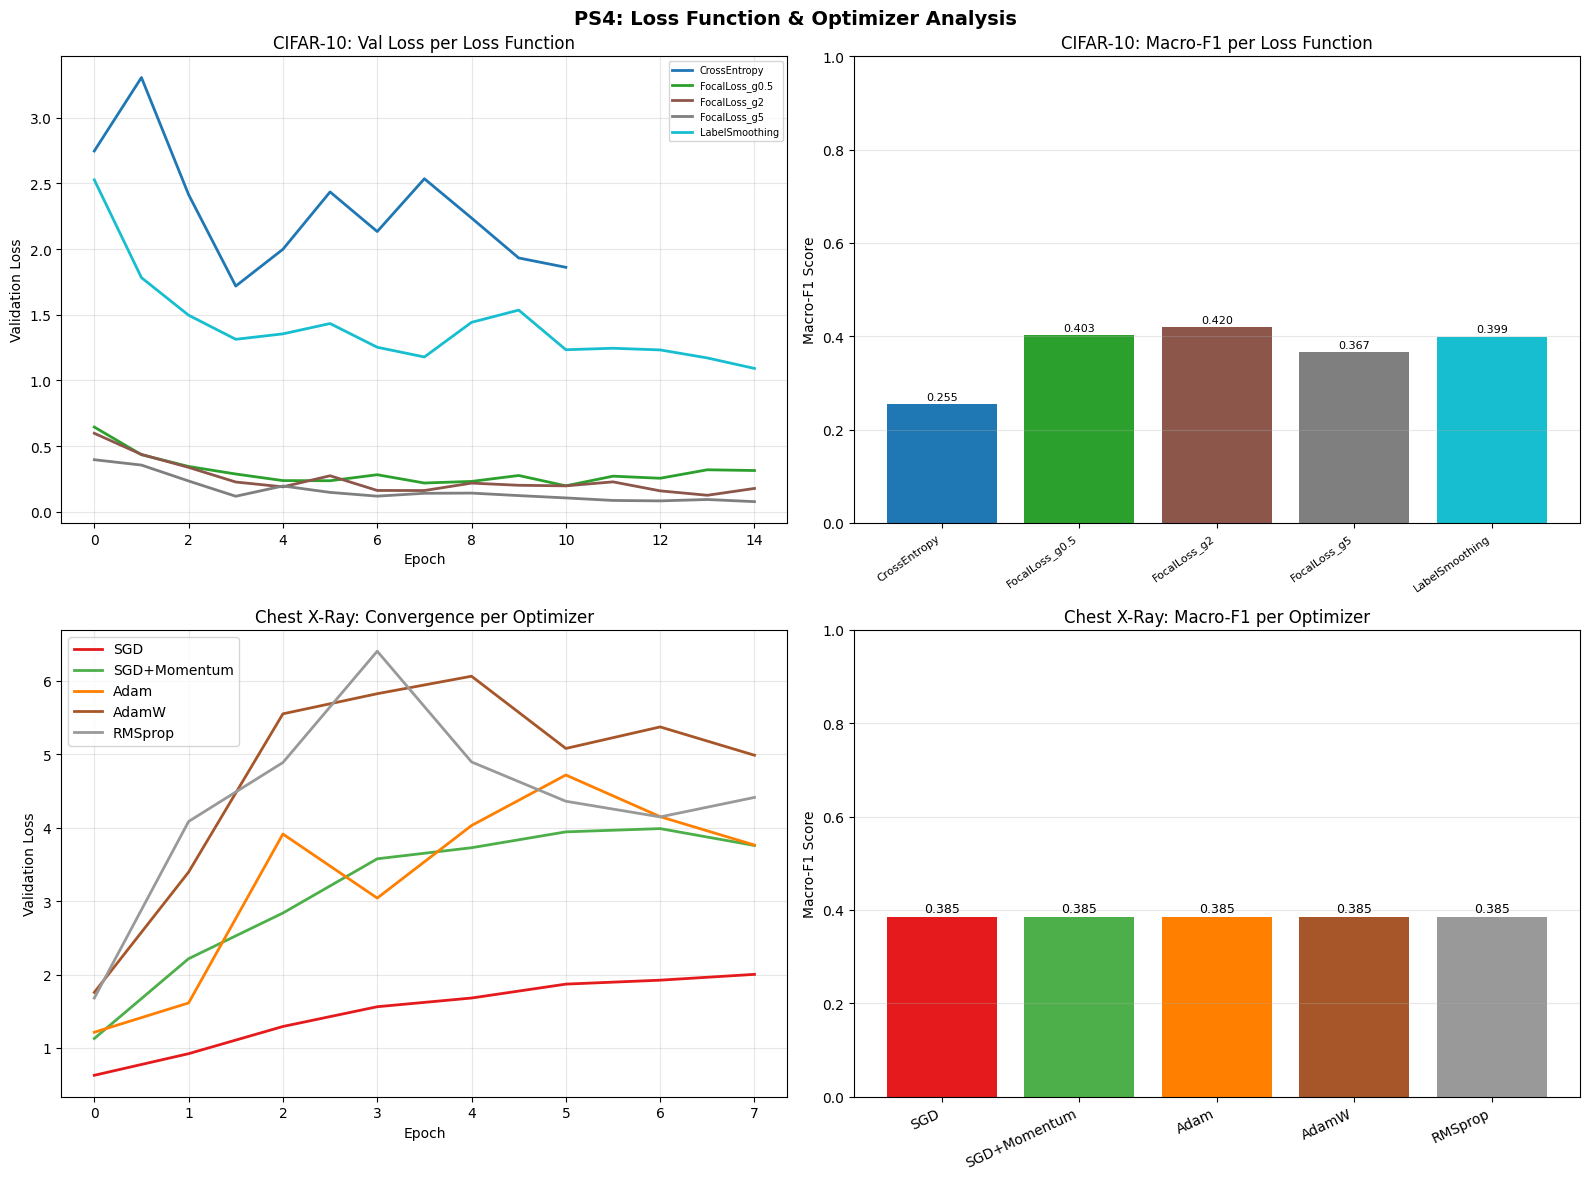


=== PS4 Summary: Loss Function Comparison (CIFAR-10) ===
  CrossEntropy             : Macro-F1=0.255, Acc=0.351, BalAcc=0.364
  FocalLoss_g0.5           : Macro-F1=0.403, Acc=0.698, BalAcc=0.405
  FocalLoss_g2             : Macro-F1=0.420, Acc=0.673, BalAcc=0.437
  FocalLoss_g5             : Macro-F1=0.367, Acc=0.663, BalAcc=0.359
  LabelSmoothing           : Macro-F1=0.399, Acc=0.713, BalAcc=0.399

=== PS4 Summary: Optimizer Comparison (Chest X-Ray) ===
  SGD            : Macro-F1=0.385, Acc=0.625, BalAcc=0.500
  SGD+Momentum   : Macro-F1=0.385, Acc=0.625, BalAcc=0.500
  Adam           : Macro-F1=0.385, Acc=0.625, BalAcc=0.500
  AdamW          : Macro-F1=0.385, Acc=0.625, BalAcc=0.500
  RMSprop        : Macro-F1=0.385, Acc=0.625, BalAcc=0.500


In [35]:
# ── PS4: Visualization ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('PS4: Loss Function & Optimizer Analysis', fontsize=14, fontweight='bold')

# Plot 1: Training loss curves for different loss functions (CIFAR-10)
ax = axes[0,0]
colors_ps4 = plt.cm.tab10(np.linspace(0, 1, len(loss_results_cifar)))
for (lname, lres), col in zip(loss_results_cifar.items(), colors_ps4):
    val_losses = lres['history'].history['val_loss']
    ax.plot(val_losses, label=lname, color=col, lw=2)
ax.set_title('CIFAR-10: Val Loss per Loss Function')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Plot 2: Macro-F1 comparison for loss functions
ax = axes[0,1]
lnames = list(loss_results_cifar.keys())
lf1s   = [loss_results_cifar[n]['macro_f1'] for n in lnames]
bars = ax.bar(lnames, lf1s, color=plt.cm.tab10(np.linspace(0,1,len(lnames))))
ax.set_title('CIFAR-10: Macro-F1 per Loss Function')
ax.set_ylabel('Macro-F1 Score')
ax.set_xticklabels(lnames, rotation=35, ha='right', fontsize=8)
for bar, f1 in zip(bars, lf1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

# Plot 3: Optimizer convergence (Chest X-Ray val loss)
ax = axes[1,0]
colors_opt = plt.cm.Set1(np.linspace(0, 1, len(opt_results_chest)))
for (oname, ores), col in zip(opt_results_chest.items(), colors_opt):
    val_losses = ores['history'].history['val_loss']
    ax.plot(val_losses, label=oname, color=col, lw=2)
ax.set_title('Chest X-Ray: Convergence per Optimizer')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Macro-F1 per optimizer
ax = axes[1,1]
onames = list(opt_results_chest.keys())
of1s   = [opt_results_chest[n]['macro_f1'] for n in onames]
bars = ax.bar(onames, of1s, color=plt.cm.Set1(np.linspace(0,1,len(onames))))
ax.set_title('Chest X-Ray: Macro-F1 per Optimizer')
ax.set_ylabel('Macro-F1 Score')
ax.set_xticklabels(onames, rotation=25, ha='right')
for bar, f1 in zip(bars, of1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.005,
            f'{f1:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ps4_loss_optimizer.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n=== PS4 Summary: Loss Function Comparison (CIFAR-10) ===")
for lname, lres in loss_results_cifar.items():
    print(f"  {lname:25s}: Macro-F1={lres['macro_f1']:.3f}, Acc={lres['accuracy']:.3f}, BalAcc={lres['balanced_acc']:.3f}")

print("\n=== PS4 Summary: Optimizer Comparison (Chest X-Ray) ===")
for oname, ores in opt_results_chest.items():
    print(f"  {oname:15s}: Macro-F1={ores['macro_f1']:.3f}, Acc={ores['accuracy']:.3f}, BalAcc={ores['balanced_acc']:.3f}")


In [36]:
# ════════════════════════════════════════════════════════
# PS5: Extract Deep Features from Best Model
# ════════════════════════════════════════════════════════

# Use the best CIFAR-10 model (EfficientNetB0 from PS3)
best_cifar_arch = max(arch_results['CIFAR10'], key=lambda k: arch_results['CIFAR10'][k]['macro_f1'])
best_chest_arch = max(arch_results['ChestXRay'], key=lambda k: arch_results['ChestXRay'][k]['macro_f1'])
print(f"Best CIFAR-10 Architecture: {best_cifar_arch}")
print(f"Best Chest X-Ray Architecture: {best_chest_arch}")

# Create feature extractor (remove final classification layer)
def get_feature_extractor(model):
    """Extract penultimate layer (before softmax/sigmoid)."""
    # Find the last Dense layer before output
    for i, layer in enumerate(model.layers[::-1]):
        if isinstance(layer, layers.Dense) and layer.name != model.layers[-1].name:
            feat_model = Model(inputs=model.input, outputs=layer.output, name='feature_extractor')
            return feat_model
    # Fallback: use GAP layer
    for layer in model.layers[::-1]:
        if isinstance(layer, layers.GlobalAveragePooling2D):
            return Model(inputs=model.input, outputs=layer.output, name='feature_extractor')

feat_extractor_cifar = get_feature_extractor(arch_models['CIFAR10'][best_cifar_arch])
feat_extractor_chest = get_feature_extractor(arch_models['ChestXRay'][best_chest_arch])

# Extract features on test sets
print("Extracting features...")
# Use a subset for speed
N_VIZ = min(1000, len(y_cifar_test))
idx_viz = np.random.choice(len(y_cifar_test), N_VIZ, replace=False)
feats_cifar = feat_extractor_cifar.predict(x_cifar_test[idx_viz], verbose=0)
labels_cifar_viz = y_cifar_test[idx_viz]

N_VIZ_CHEST = min(500, len(y_chest_test))
idx_viz_c = np.random.choice(len(y_chest_test), N_VIZ_CHEST, replace=False)
feats_chest = feat_extractor_chest.predict(x_chest_test[idx_viz_c], verbose=0)
labels_chest_viz = y_chest_test[idx_viz_c]

print(f"CIFAR-10 feature shape: {feats_cifar.shape}")
print(f"Chest X-Ray feature shape: {feats_chest.shape}")


Best CIFAR-10 Architecture: MobileNetV2
Best Chest X-Ray Architecture: MobileNetV2
Extracting features...


2026-03-01 11:05:11.888488: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:05:12.038386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:05:12.175054: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:05:26.041867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:05:26.183450: E external/local_xla/xla/stream_

CIFAR-10 feature shape: (1000, 256)
Chest X-Ray feature shape: (500, 256)


In [37]:
# ── PCA ──
print("Running PCA...")
pca_cifar = PCA(n_components=2, random_state=SEED)
pca_feat_cifar = pca_cifar.fit_transform(feats_cifar)
print(f"  CIFAR-10 PCA variance explained: {pca_cifar.explained_variance_ratio_.sum():.3f}")

pca_chest = PCA(n_components=2, random_state=SEED)
pca_feat_chest = pca_chest.fit_transform(feats_chest)

# ── t-SNE ──
print("Running t-SNE (may take a few minutes)...")
# First reduce dims with PCA to speed up t-SNE
pca_50 = PCA(n_components=min(50, feats_cifar.shape[1]), random_state=SEED)
feats_cifar_50 = pca_50.fit_transform(feats_cifar)
tsne_cifar = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
tsne_feat_cifar = tsne_cifar.fit_transform(feats_cifar_50)

pca_50c = PCA(n_components=min(50, feats_chest.shape[1]), random_state=SEED)
feats_chest_50 = pca_50c.fit_transform(feats_chest)
tsne_chest = TSNE(n_components=2, random_state=SEED, perplexity=20, n_iter=1000)
tsne_feat_chest = tsne_chest.fit_transform(feats_chest_50)
print("t-SNE complete!")


Running PCA...
  CIFAR-10 PCA variance explained: 0.313
Running t-SNE (may take a few minutes)...
t-SNE complete!


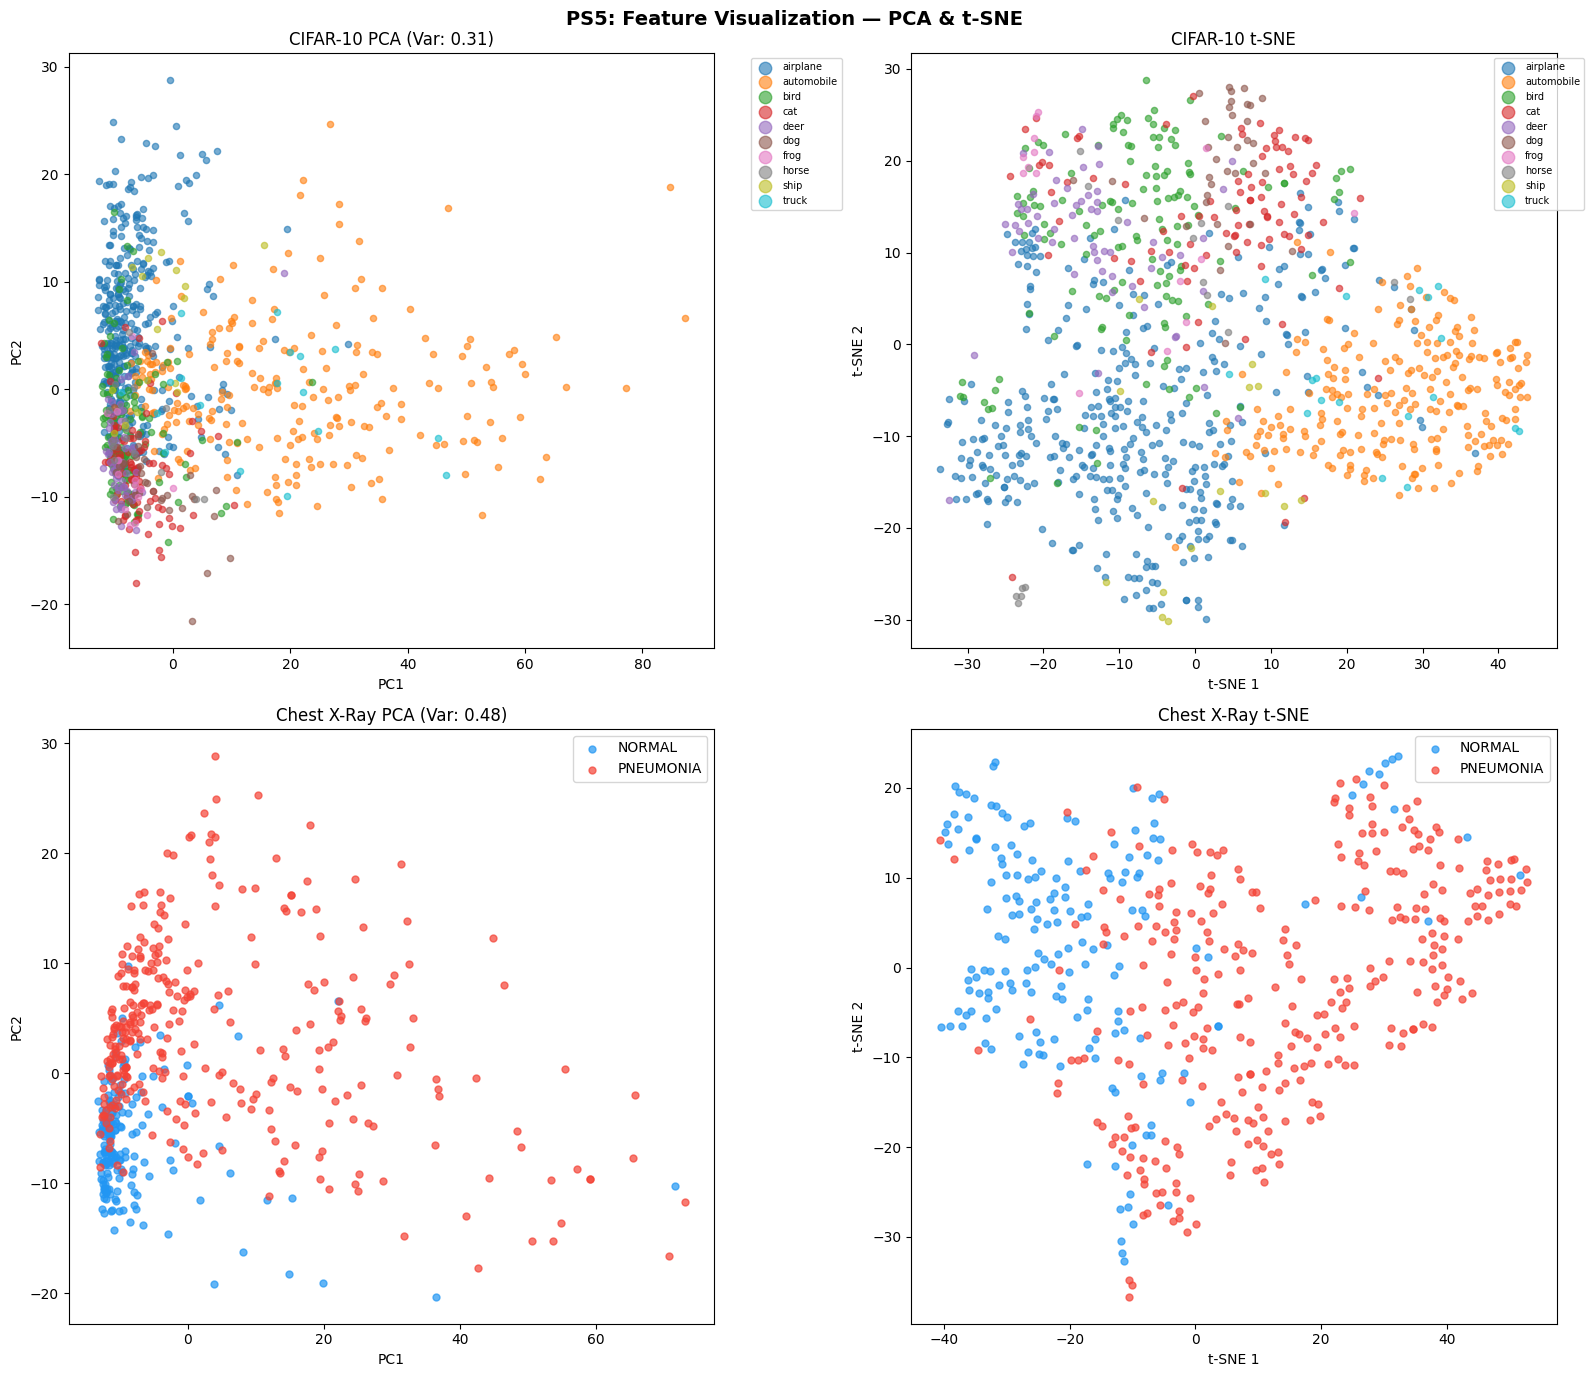

In [38]:
# ── Visualize PCA & t-SNE ──
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('PS5: Feature Visualization — PCA & t-SNE', fontsize=14, fontweight='bold')

colors10 = plt.cm.tab10(np.arange(10)/10)
colors2  = ['#2196F3','#F44336']

# CIFAR-10 PCA
ax = axes[0,0]
for c in range(NUM_CIFAR):
    mask = labels_cifar_viz == c
    ax.scatter(pca_feat_cifar[mask,0], pca_feat_cifar[mask,1],
               c=[colors10[c]], label=CIFAR_CLASSES[c], alpha=0.6, s=20)
ax.set_title(f'CIFAR-10 PCA (Var: {pca_cifar.explained_variance_ratio_.sum():.2f})')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.05,1))
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# CIFAR-10 t-SNE
ax = axes[0,1]
for c in range(NUM_CIFAR):
    mask = labels_cifar_viz == c
    ax.scatter(tsne_feat_cifar[mask,0], tsne_feat_cifar[mask,1],
               c=[colors10[c]], label=CIFAR_CLASSES[c], alpha=0.6, s=20)
ax.set_title('CIFAR-10 t-SNE')
ax.legend(fontsize=7, markerscale=2, bbox_to_anchor=(1.05,1))
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

# Chest PCA
ax = axes[1,0]
for c in range(2):
    mask = labels_chest_viz == c
    ax.scatter(pca_feat_chest[mask,0], pca_feat_chest[mask,1],
               c=colors2[c], label=CHEST_CLASSES[c], alpha=0.7, s=25)
ax.set_title(f'Chest X-Ray PCA (Var: {pca_chest.explained_variance_ratio_.sum():.2f})')
ax.legend()
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

# Chest t-SNE
ax = axes[1,1]
for c in range(2):
    mask = labels_chest_viz == c
    ax.scatter(tsne_feat_chest[mask,0], tsne_feat_chest[mask,1],
               c=colors2[c], label=CHEST_CLASSES[c], alpha=0.7, s=25)
ax.set_title('Chest X-Ray t-SNE')
ax.legend()
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('ps5_pca_tsne.png', dpi=120, bbox_inches='tight')
plt.show()


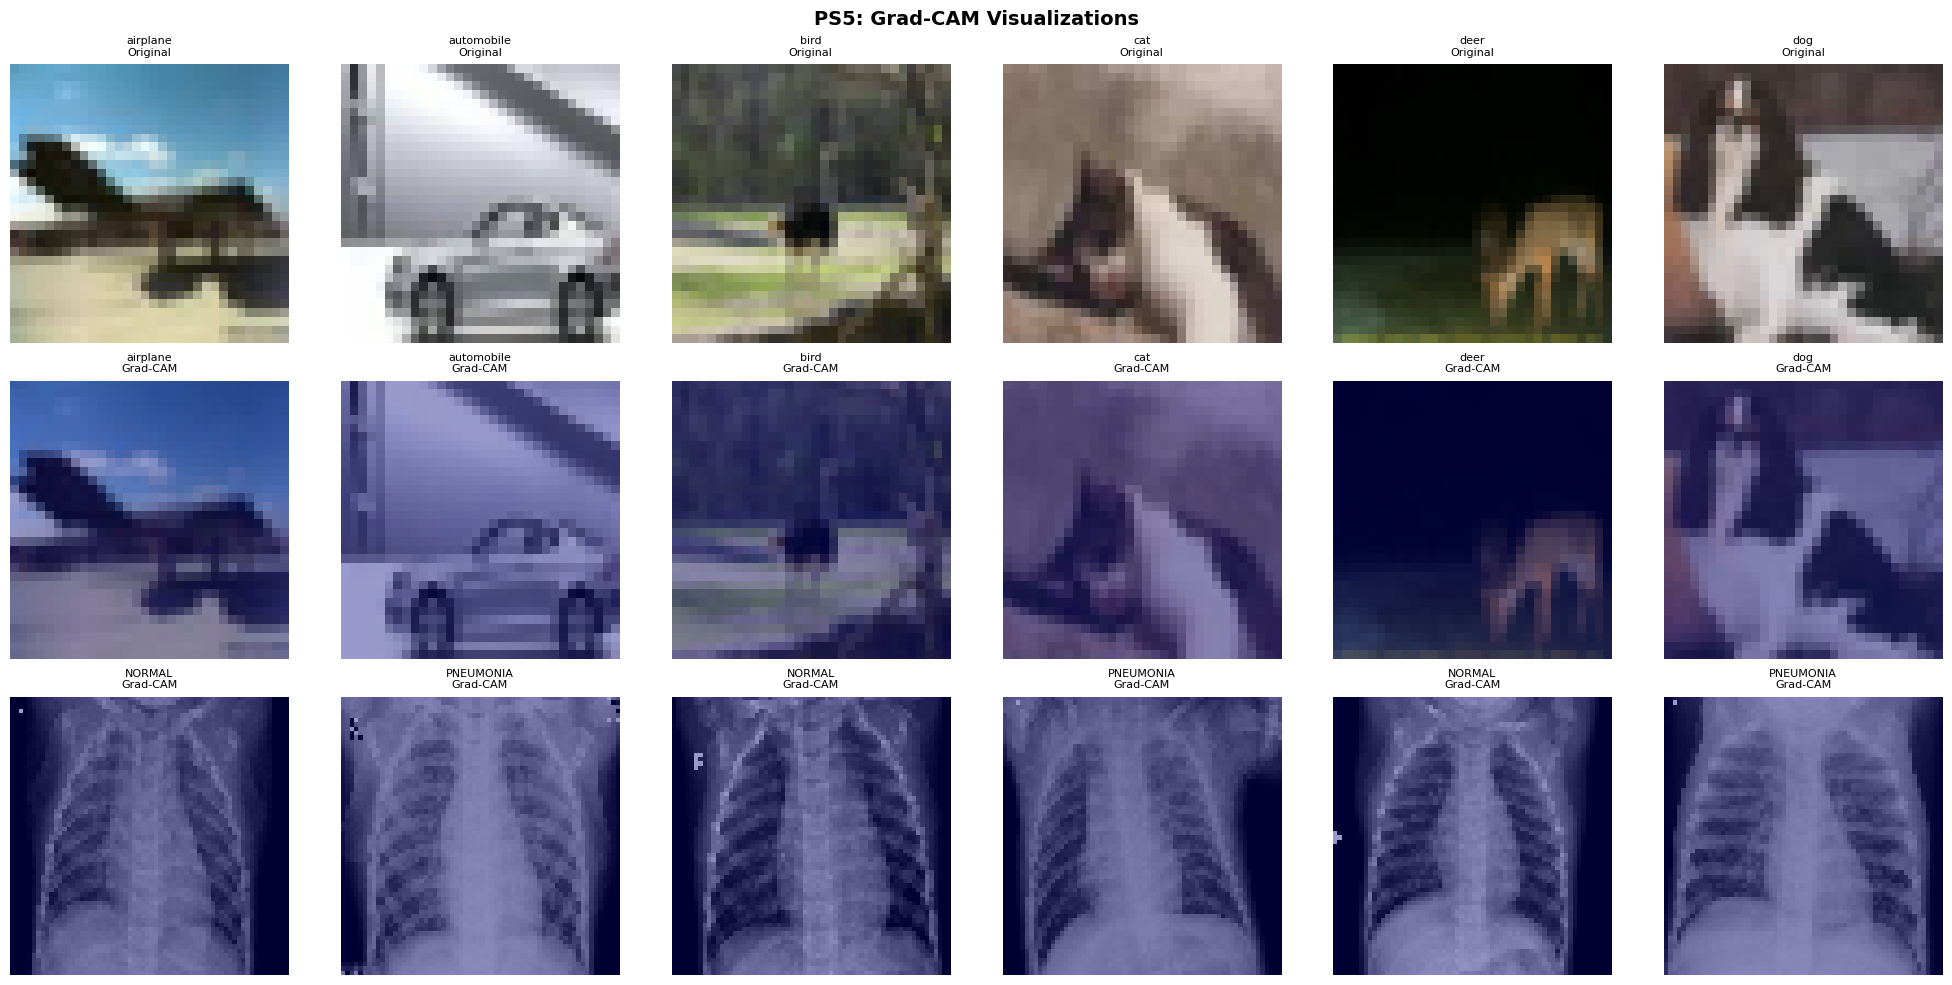

Grad-CAM visualization complete!


In [39]:
# ── Grad-CAM Implementation ──
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None):
    """Generate Grad-CAM heatmap for given image and model."""
    # Find last conv layer automatically if not specified
    if last_conv_layer_name is None:
        for layer in reversed(model.layers):
            if isinstance(layer, layers.Conv2D):
                last_conv_layer_name = layer.name
                break
    
    grad_model = Model(inputs=model.inputs,
                       outputs=[model.get_layer(last_conv_layer_name).output,
                                model.output])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if predictions.shape[-1] > 1:
            pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]
        else:
            class_channel = predictions[:, 0]
    
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_heatmap(img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on original image."""
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    img_uint8 = np.uint8(255 * img)
    superimposed = cv2.addWeighted(img_uint8, 1-alpha, heatmap_colored, alpha, 0)
    return superimposed

# ── Generate Grad-CAM for best models ──
fig, axes = plt.subplots(3, 6, figsize=(20, 10))
fig.suptitle('PS5: Grad-CAM Visualizations', fontsize=14, fontweight='bold')

best_model_cifar = arch_models['CIFAR10'][best_cifar_arch]
best_model_chest = arch_models['ChestXRay'][best_chest_arch]

# CIFAR-10: Show 6 classes with their Grad-CAMs
classes_to_show = [0, 1, 2, 3, 4, 5]
for col, c in enumerate(classes_to_show):
    idx = np.where(y_cifar_test == c)[0][0]
    img = x_cifar_test[idx]
    img_exp = np.expand_dims(img, 0)
    try:
        heatmap = make_gradcam_heatmap(img_exp, best_model_cifar)
        overlay = overlay_heatmap(img, heatmap)
        axes[0,col].imshow(img)
        axes[0,col].set_title(f'{CIFAR_CLASSES[c]}\nOriginal', fontsize=8)
        axes[0,col].axis('off')
        axes[1,col].imshow(overlay)
        axes[1,col].set_title(f'{CIFAR_CLASSES[c]}\nGrad-CAM', fontsize=8)
        axes[1,col].axis('off')
    except Exception as e:
        axes[0,col].text(0.5, 0.5, f'Error', ha='center')
        axes[1,col].text(0.5, 0.5, str(e)[:30], ha='center', fontsize=6)

# Chest X-Ray Grad-CAM
for col, c in enumerate([0,1,2,3,4,5]):
    class_c = c % 2
    idx = np.where(y_chest_test == class_c)[0][col//2]
    img = x_chest_test[idx]
    img_exp = np.expand_dims(img, 0)
    try:
        heatmap = make_gradcam_heatmap(img_exp, best_model_chest)
        overlay = overlay_heatmap(img, heatmap)
        axes[2,col].imshow(overlay)
        axes[2,col].set_title(f'{CHEST_CLASSES[class_c]}\nGrad-CAM', fontsize=8)
        axes[2,col].axis('off')
    except Exception as e:
        axes[2,col].text(0.5, 0.5, str(e)[:30], ha='center', fontsize=6)

axes[0,0].set_ylabel('Original', fontsize=10)
axes[1,0].set_ylabel('CIFAR-10\nGrad-CAM', fontsize=9)
axes[2,0].set_ylabel('Chest X-Ray\nGrad-CAM', fontsize=9)

plt.tight_layout()
plt.savefig('ps5_gradcam.png', dpi=120, bbox_inches='tight')
plt.show()
print("Grad-CAM visualization complete!")


In [40]:
# ════════════════════════════════════════════════════════
# PS6: Transfer Learning Experiments
# Experiment: CIFAR-10 pretrained model → Chest X-Ray (cross-domain)
# Also: Feature extraction vs Fine-tuning comparison
# ════════════════════════════════════════════════════════

def build_pretrained_from_cifar(cifar_model, target_input_shape=(64,64,3)):
    """
    Transfer a CIFAR-10 trained model's feature extractor to Chest X-Ray task.
    Freeze all layers except the final dense layers.
    """
    inputs = keras.Input(shape=target_input_shape)
    x = layers.Resizing(32, 32)(inputs)  # Resize to match CIFAR input
    
    # Rebuild same architecture; we'll transfer weights
    # Strategy: use the architecture backbone with frozen weights
    backbone = feat_extractor_cifar  # Use the feature extractor we already built
    
    # Freeze backbone
    backbone.trainable = False
    
    x = backbone(x, training=False)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs, outputs, name='CIFAR_to_Chest_FeatureExtract')
    return model

# ─── Mode A: Feature Extraction (backbone frozen) ───
print("=== Mode A: Feature Extraction (Frozen Backbone) ===")
model_transfer_frozen = build_pretrained_from_cifar(arch_models['CIFAR10'][best_cifar_arch])
model_transfer_frozen.compile(optimizer=keras.optimizers.Adam(1e-3),
                               loss='binary_crossentropy',
                               metrics=['accuracy'])
model_transfer_frozen.summary()

hist_frozen = model_transfer_frozen.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=15, batch_size=BATCH_SIZE,
    class_weight=cw_chest,
    callbacks=callbacks_base,
    verbose=1
)

# ─── Mode B: Fine-Tuning (unfreeze last few layers) ───
print("\n=== Mode B: Fine-Tuning (Partial Unfreeze) ===")
model_transfer_finetune = build_pretrained_from_cifar(arch_models['CIFAR10'][best_cifar_arch])
# Unfreeze last layers of backbone
for layer in model_transfer_finetune.layers:
    if hasattr(layer, 'layers'):  # It's a sub-model
        for sublayer in layer.layers[-10:]:
            sublayer.trainable = True

model_transfer_finetune.compile(optimizer=keras.optimizers.Adam(1e-4),  # Lower LR for fine-tuning
                                 loss='binary_crossentropy',
                                 metrics=['accuracy'])

hist_finetune = model_transfer_finetune.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=15, batch_size=BATCH_SIZE,
    class_weight=cw_chest,
    callbacks=callbacks_base,
    verbose=1
)


=== Mode A: Feature Extraction (Frozen Backbone) ===


Model: "CIFAR_to_Chest_FeatureExtract"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_34 (InputLayer)     │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_8 (Resizing)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor (Functional)  │ (None, 256)            │     2,591,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_112 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,624,065 (10.01 MB)

 Trainable params: 33,025 (129.00 KB)

...

Epoch 1/15


2026-03-01 11:07:55.998081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:07:56.136532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7474 - loss: 0.5616

2026-03-01 11:08:15.055484: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:08:15.208386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:08:15.346091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 34s 377ms/step - accuracy: 0.7486 - loss: 0.5590 - val_accuracy: 0.8799 - val_loss: 0.2658 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8743 - loss: 0.2779 - val_accuracy: 0.8958 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8839 - loss: 0.2483 - val_accuracy: 0.9117 - val_loss: 0.2165 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9091 - loss: 0.2027 - val_accuracy: 0.9134 - val_loss: 0.2011 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9105 - loss: 0.1869 - val_accuracy: 0.9134 - val_loss: 0.2043 - learning_rate: 0.0010
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9229 - loss: 0.1746 - val_accuracy: 0.9170 - val_loss: 0.1996 - learning_rate: 0.0010
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9226 - loss: 0.1659 - val_accuracy: 0.

In [41]:
# ─── Mode A: Feature Extraction (Frozen Backbone) ───
print("=== Mode A: Feature Extraction (Frozen Backbone) ===")

def build_pretrained_from_cifar(target_input_shape=(64,64,3)):
    inputs = keras.Input(shape=target_input_shape)
    x = layers.Resizing(32, 32)(inputs)
    backbone = feat_extractor_cifar
    backbone.trainable = False
    x = backbone(x, training=False)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs, name='CIFAR_to_Chest_FeatureExtract')
    return model

model_transfer_frozen = build_pretrained_from_cifar()
model_transfer_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_frozen = model_transfer_frozen.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=15, batch_size=BATCH_SIZE,
    class_weight=cw_chest,
    callbacks=callbacks_base,
    verbose=1
)
print("✅ Mode A done!")

=== Mode A: Feature Extraction (Frozen Backbone) ===
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 266ms/step - accuracy: 0.8666 - loss: 0.3356 - val_accuracy: 0.7491 - val_loss: 15.6650 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9434 - loss: 0.1333 - val_accuracy: 0.7527 - val_loss: 15.6248 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9647 - loss: 0.0885 - val_accuracy: 0.7438 - val_loss: 27.8608 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9715 - loss: 0.0682 - val_accuracy: 0.7615 - val_loss: 20.9026 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9808 - loss: 0.0418 - val_accuracy: 0.7686 - val_loss: 17.7093 - learning_rate: 0.0010
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9846 - loss: 0.0387 - val_accuracy: 0.7650 - val_loss: 14.4279 - learning_rate: 5.0000e-04
Epoch 7/15
51/51 ━━━━━━━━━━━━

In [42]:
# ─── Mode B: Fine-Tuning (Partial Unfreeze) ───
print("=== Mode B: Fine-Tuning (Partial Unfreeze) ===")

import gc
gc.collect()

model_transfer_finetune = build_pretrained_from_cifar()

# Unfreeze last layers of backbone
for layer in model_transfer_finetune.layers:
    if hasattr(layer, 'layers'):
        for sublayer in layer.layers[-10:]:
            sublayer.trainable = True

model_transfer_finetune.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

hist_finetune = model_transfer_finetune.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=15, batch_size=BATCH_SIZE,
    class_weight=cw_chest,
    callbacks=callbacks_base,
    verbose=1
)
print("✅ Mode B done!")

=== Mode B: Fine-Tuning (Partial Unfreeze) ===
Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 25s 271ms/step - accuracy: 0.8898 - loss: 0.2487 - val_accuracy: 0.9152 - val_loss: 0.5856 - learning_rate: 1.0000e-04
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9944 - loss: 0.0210 - val_accuracy: 0.9152 - val_loss: 0.6161 - learning_rate: 1.0000e-04
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9980 - loss: 0.0119 - val_accuracy: 0.9187 - val_loss: 0.5991 - learning_rate: 1.0000e-04
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9977 - loss: 0.0079 - val_accuracy: 0.9223 - val_loss: 0.5652 - learning_rate: 1.0000e-04
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9988 - loss: 0.0047 - val_accuracy: 0.9382 - val_loss: 0.4726 - learning_rate: 1.0000e-04
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9998 - loss: 0.0028 - val_accuracy: 0.9417 - val_loss: 0.4706 - learning_rate: 1.0000e-04
Epoch 7/15
51/51 ━━━━

=== Mode C: ImageNet → Chest X-Ray (EfficientNetB0) ===
Epoch 1/15


2026-03-01 11:12:13.839409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:13.975034: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:14.305302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:14.447468: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:15.233885: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.5034 - loss: 0.9039

2026-03-01 11:12:43.559118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:43.694109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:44.019907: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:44.161796: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-01 11:12:44.918768: E external/local_xla/xla/stream_

51/51 ━━━━━━━━━━━━━━━━━━━━ 51s 526ms/step - accuracy: 0.5035 - loss: 0.9035 - val_accuracy: 0.7420 - val_loss: 0.6630 - learning_rate: 0.0010
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4948 - loss: 0.8691 - val_accuracy: 0.7420 - val_loss: 0.6823 - learning_rate: 0.0010
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5163 - loss: 0.8467 - val_accuracy: 0.7509 - val_loss: 0.6886 - learning_rate: 0.0010
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5181 - loss: 0.8110 - val_accuracy: 0.7420 - val_loss: 0.6821 - learning_rate: 0.0010
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5458 - loss: 0.7654 - val_accuracy: 0.7420 - val_loss: 0.6813 - learning_rate: 5.0000e-04
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5125 - loss: 0.7424 - val_accuracy: 0.7420 - val_loss: 0.6869 - learning_rate: 5.0000e-04
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5099 - loss: 0.7218 - val_accu

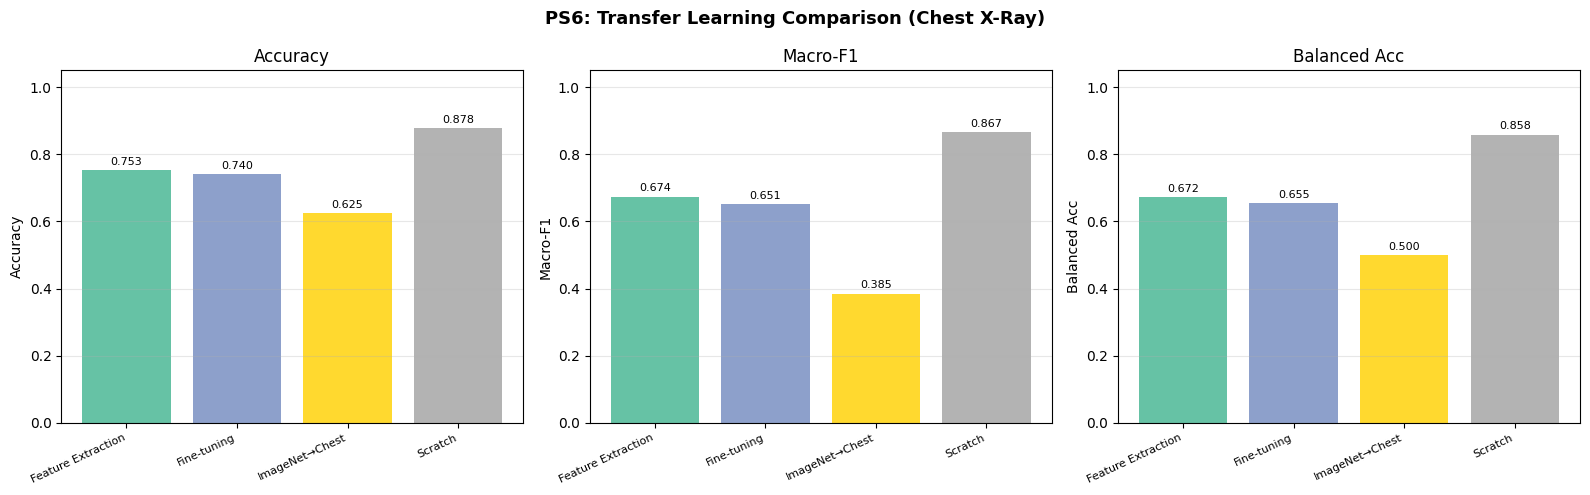

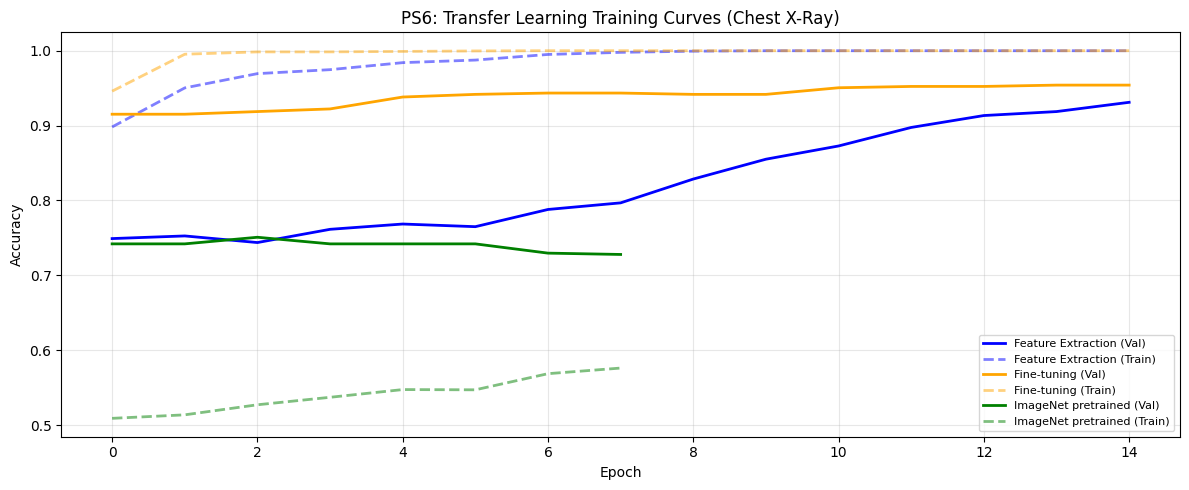

In [43]:
# ─── Mode C: ImageNet Pretrained → Chest X-Ray ───
print("=== Mode C: ImageNet → Chest X-Ray (EfficientNetB0) ===")
model_imagenet, _ = build_transfer_model('EfficientNetB0', 2, (64,64,3), binary=True)
model_imagenet.compile(optimizer=keras.optimizers.Adam(1e-3),
                       loss='binary_crossentropy', metrics=['accuracy'])

hist_imagenet = model_imagenet.fit(
    x_chest_train, y_chest_train,
    validation_data=(x_chest_val, y_chest_val),
    epochs=15, batch_size=BATCH_SIZE,
    class_weight=cw_chest,
    callbacks=callbacks_base,
    verbose=1
)

# ─── Evaluate All Transfer Learning Modes ───
transfer_modes = {
    'Feature Extraction (CIFAR→Chest)': model_transfer_frozen,
    'Fine-tuning (CIFAR→Chest)':        model_transfer_finetune,
    'ImageNet→Chest (EfficientNet)':    model_imagenet,
    'Scratch (Custom CNN)':             model_chest_cw,
}

print("\n=== PS6: Transfer Learning Comparison ===")
tl_results = {}
for name, mdl in transfer_modes.items():
    probs = mdl.predict(x_chest_test).flatten()
    preds = (probs > 0.5).astype(int)
    acc  = np.mean(preds == y_chest_test)
    mf1  = f1_score(y_chest_test, preds, average='macro')
    ba   = balanced_accuracy_score(y_chest_test, preds)
    tl_results[name] = {'Accuracy': acc, 'Macro-F1': mf1, 'Balanced Acc': ba}
    print(f"  {name:40s}: Acc={acc:.3f} | Macro-F1={mf1:.3f} | BalAcc={ba:.3f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('PS6: Transfer Learning Comparison (Chest X-Ray)', fontsize=13, fontweight='bold')
metrics = ['Accuracy', 'Macro-F1', 'Balanced Acc']
colors_tl = plt.cm.Set2(np.linspace(0, 1, len(tl_results)))
for ax, metric in zip(axes, metrics):
    vals = [tl_results[n][metric] for n in tl_results]
    names = list(tl_results.keys())
    bars = ax.bar(range(len(names)), vals, color=colors_tl)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.split('(')[0].strip() for n in names], rotation=25, ha='right', fontsize=8)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('ps6_transfer_learning.png', dpi=120, bbox_inches='tight')
plt.show()

# Training curve comparison
plt.figure(figsize=(12, 5))
for (name, hist), color in zip([('Feature Extraction', hist_frozen),
                                  ('Fine-tuning', hist_finetune),
                                  ('ImageNet pretrained', hist_imagenet)],
                                 ['blue','orange','green']):
    plt.plot(hist.history['val_accuracy'], label=name+' (Val)', color=color, lw=2)
    plt.plot(hist.history['accuracy'], label=name+' (Train)', color=color, lw=2, linestyle='--', alpha=0.5)
plt.title('PS6: Transfer Learning Training Curves (Chest X-Ray)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ps6_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [44]:
# ════════════════════════════════════════════════════════
# PS7: Comprehensive Error Analysis
# ════════════════════════════════════════════════════════

# Use best models from PS3
best_cifar_model = arch_models['CIFAR10'][best_cifar_arch]
best_chest_model = arch_models['ChestXRay'][best_chest_arch]

# ─── CIFAR-10 Error Analysis ───
preds_cifar = np.argmax(best_cifar_model.predict(x_cifar_test), axis=1)
probs_cifar = best_cifar_model.predict(x_cifar_test)

wrong_mask = preds_cifar != y_cifar_test
wrong_idx  = np.where(wrong_mask)[0]
print(f"CIFAR-10: Total errors: {len(wrong_idx)}/{len(y_cifar_test)} ({len(wrong_idx)/len(y_cifar_test)*100:.1f}%)")

# Per-class error rates
print("\nPer-class error analysis (CIFAR-10):")
class_errors = {}
for c in range(NUM_CIFAR):
    c_mask   = y_cifar_test == c
    c_wrong  = (preds_cifar[c_mask] != c).sum()
    c_total  = c_mask.sum()
    c_rate   = c_wrong / c_total if c_total > 0 else 0
    class_errors[CIFAR_CLASSES[c]] = {'errors': int(c_wrong), 'total': int(c_total), 'error_rate': c_rate}
    print(f"  {CIFAR_CLASSES[c]:12s}: {c_wrong:3d}/{c_total:4d} errors ({c_rate*100:.1f}%)")

# ─── Confusion Analysis ───
cm_cifar = confusion_matrix(y_cifar_test, preds_cifar)
# Find most confused pairs
confused_pairs = []
for i in range(NUM_CIFAR):
    for j in range(NUM_CIFAR):
        if i != j and cm_cifar[i,j] > 0:
            confused_pairs.append((CIFAR_CLASSES[i], CIFAR_CLASSES[j], cm_cifar[i,j]))
confused_pairs.sort(key=lambda x: -x[2])

print("\nTop 10 Most Confused Class Pairs (CIFAR-10):")
print(f"  {'True Class':15s} → {'Pred Class':15s}: Count")
for true_c, pred_c, cnt in confused_pairs[:10]:
    print(f"  {true_c:15s} → {pred_c:15s}: {cnt:4d}")


81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
CIFAR-10: Total errors: 1643/2579 (63.7%)

Per-class error analysis (CIFAR-10):
  airplane    : 456/1000 errors (45.6%)
  automobile  : 282/ 599 errors (47.1%)
  bird        : 319/ 359 errors (88.9%)
  cat         : 190/ 215 errors (88.4%)
  deer        : 124/ 129 errors (96.1%)
  dog         :  75/  77 errors (97.4%)
  frog        :  47/  50 errors (94.0%)
  horse       :  50/  50 errors (100.0%)
  ship        :  50/  50 errors (100.0%)
  truck       :  50/  50 errors (100.0%)

Top 10 Most Confused Class Pairs (CIFAR-10):
  True Class      → Pred Class     : Count
  airplane        → automobile     :  315
  automobile      → airplane       :  216
  bird            → airplane       :  174
  bird            → automobile     :  103
  deer            → automobile     :   76
  cat             → airplane       :   73
  airplane        → bird           :   55
  cat             → automobile     :   50
  airplane    

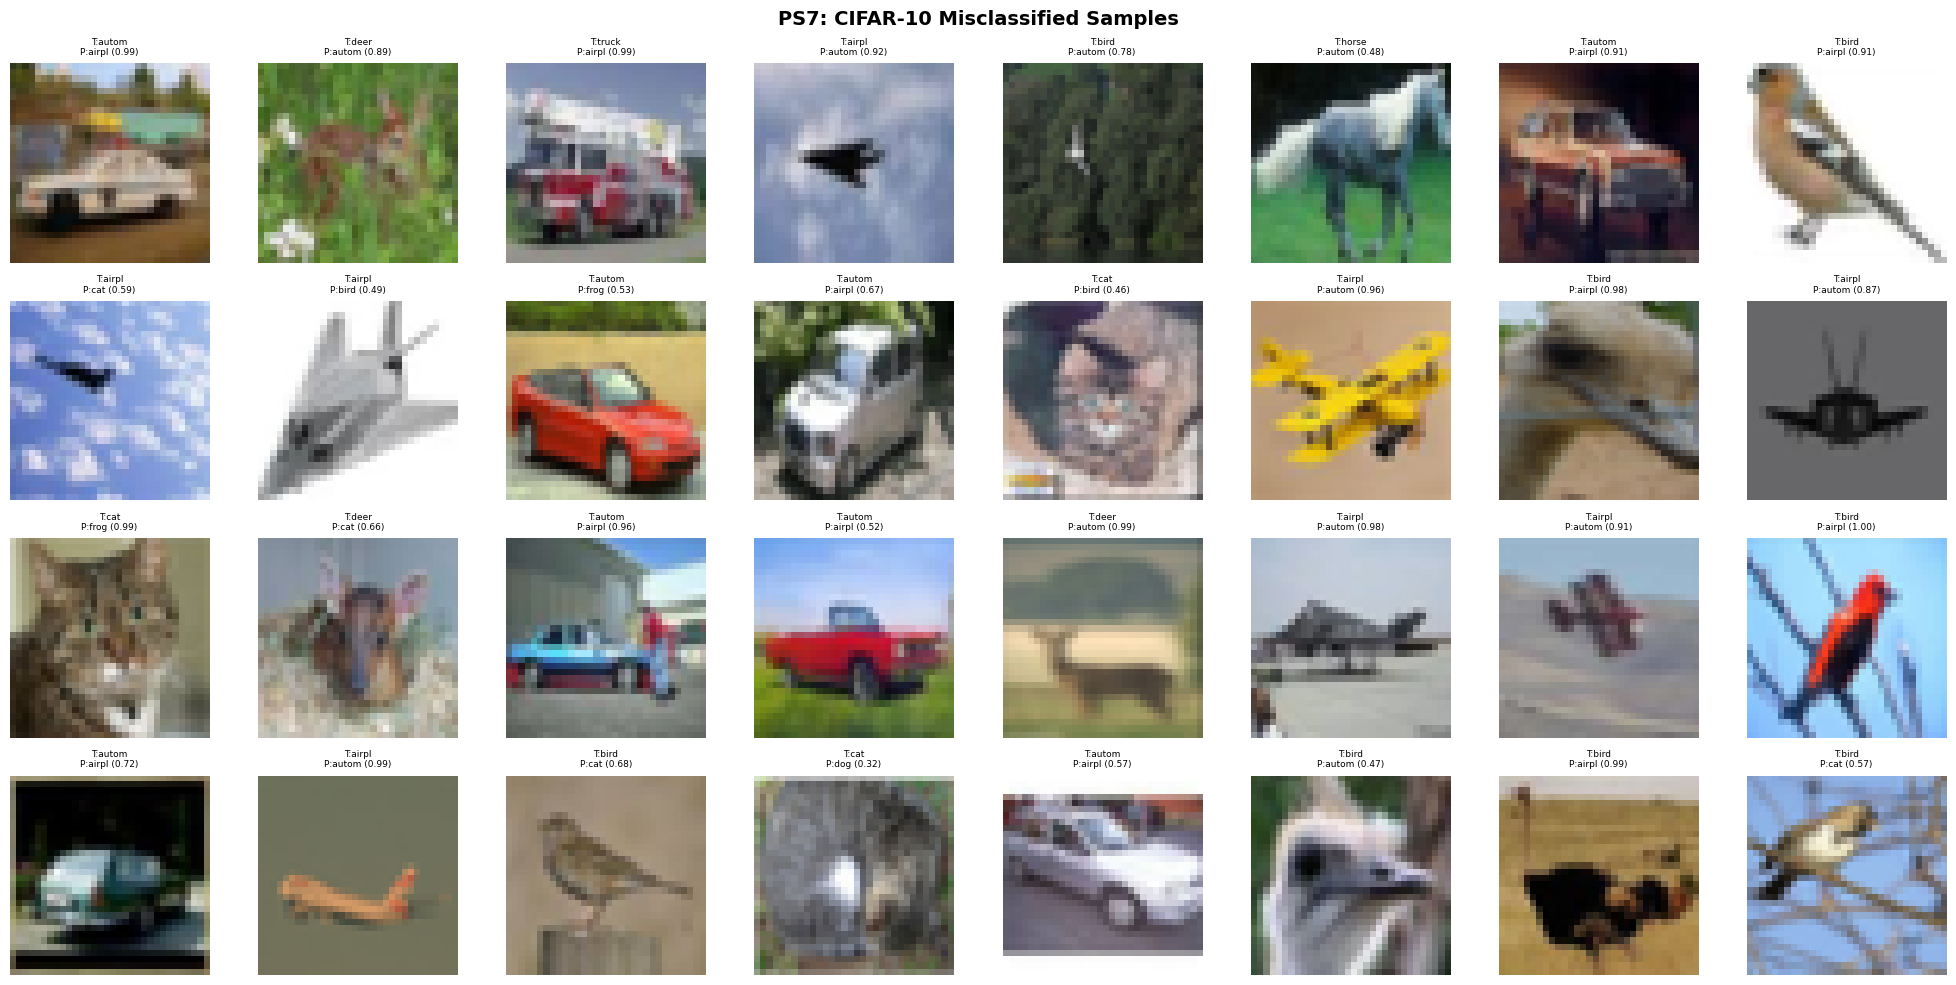

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

Chest X-Ray Error Analysis:
  Total errors: 112/624 (17.9%)
  False Negatives (Missed Pneumonia): 6 — CRITICAL!
  False Positives (False Alarm):      106
  Low-confidence correct: 30 (uncertain predictions)


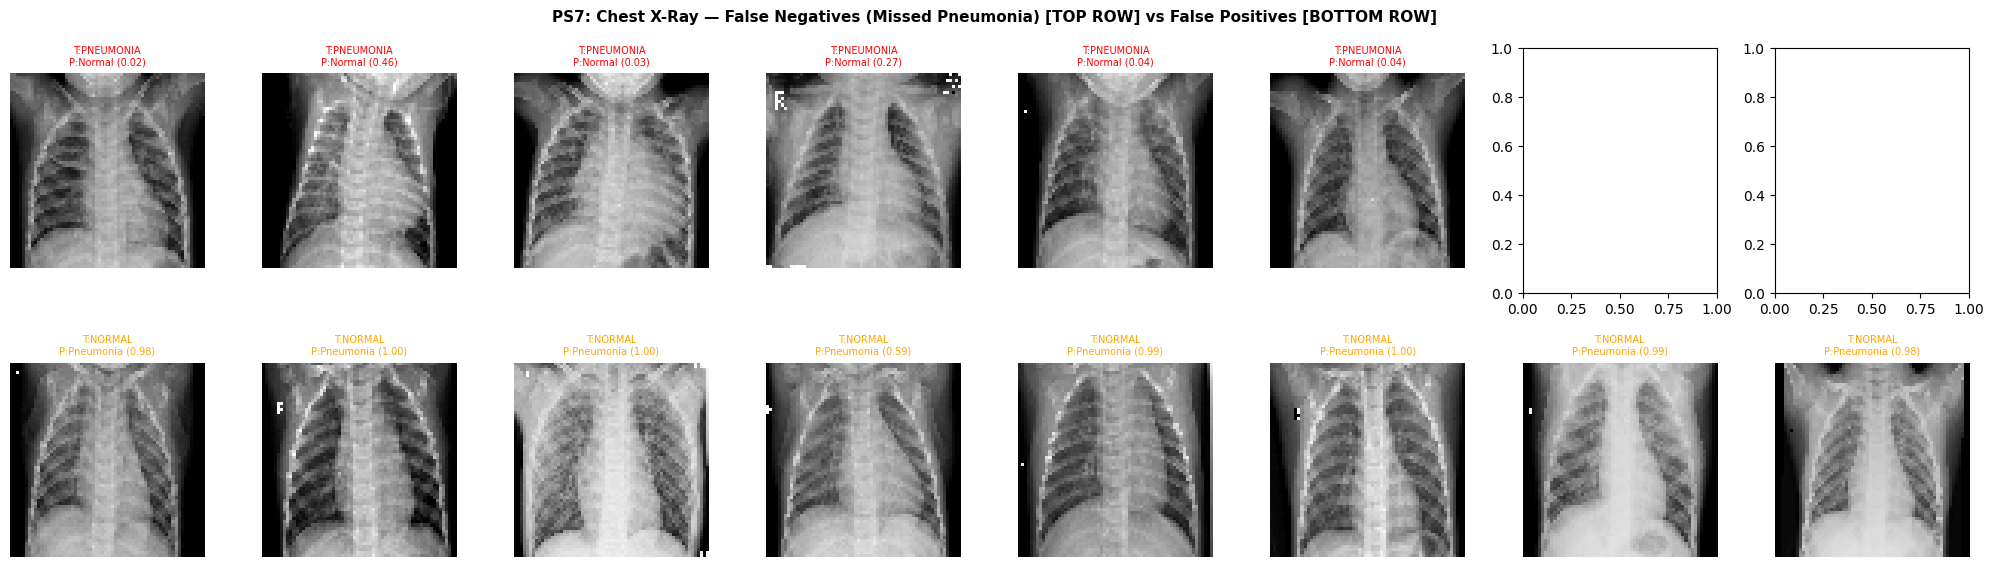

In [45]:
# ─── Visualize Misclassified Samples ───
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('PS7: CIFAR-10 Misclassified Samples', fontsize=14, fontweight='bold')

np.random.shuffle(wrong_idx)
shown = 0
for ax, idx in zip(axes.flatten(), wrong_idx[:32]):
    ax.imshow(x_cifar_test[idx])
    true_lbl  = CIFAR_CLASSES[y_cifar_test[idx]]
    pred_lbl  = CIFAR_CLASSES[preds_cifar[idx]]
    confidence = probs_cifar[idx][preds_cifar[idx]]
    ax.set_title(f'T:{true_lbl[:5]}\nP:{pred_lbl[:5]} ({confidence:.2f})', fontsize=6.5)
    ax.axis('off')
    shown += 1

# Hide remaining axes
for ax in axes.flatten()[shown:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('ps7_misclassified_cifar.png', dpi=120, bbox_inches='tight')
plt.show()

# ─── Chest X-Ray Error Analysis ───
probs_chest_best = best_chest_model.predict(x_chest_test).flatten()
preds_chest_best = (probs_chest_best > 0.5).astype(int)

wrong_chest = preds_chest_best != y_chest_test
fn_mask = (y_chest_test == 1) & (preds_chest_best == 0)  # False Negatives (missed pneumonia)
fp_mask = (y_chest_test == 0) & (preds_chest_best == 1)  # False Positives (false alarm)

print(f"\nChest X-Ray Error Analysis:")
print(f"  Total errors: {wrong_chest.sum()}/{len(y_chest_test)} ({wrong_chest.mean()*100:.1f}%)")
print(f"  False Negatives (Missed Pneumonia): {fn_mask.sum()} — CRITICAL!")
print(f"  False Positives (False Alarm):      {fp_mask.sum()}")

# Low confidence correct predictions
correct_mask = preds_chest_best == y_chest_test
confident_mask = np.abs(probs_chest_best - 0.5) > 0.3
low_conf_correct = correct_mask & ~confident_mask
print(f"  Low-confidence correct: {low_conf_correct.sum()} (uncertain predictions)")

# Visualize false negatives (most critical for medical imaging)
fn_idx = np.where(fn_mask)[0]
fig, axes = plt.subplots(2, 8, figsize=(20, 6))
fig.suptitle('PS7: Chest X-Ray — False Negatives (Missed Pneumonia) [TOP ROW] vs False Positives [BOTTOM ROW]',
             fontsize=11, fontweight='bold')

fp_idx = np.where(fp_mask)[0]
for col in range(8):
    if col < len(fn_idx):
        axes[0,col].imshow(x_chest_test[fn_idx[col]], cmap='gray')
        conf = probs_chest_best[fn_idx[col]]
        axes[0,col].set_title(f'T:PNEUMONIA\nP:Normal ({conf:.2f})', fontsize=7, color='red')
        axes[0,col].axis('off')
    if col < len(fp_idx):
        axes[1,col].imshow(x_chest_test[fp_idx[col]], cmap='gray')
        conf = probs_chest_best[fp_idx[col]]
        axes[1,col].set_title(f'T:NORMAL\nP:Pneumonia ({conf:.2f})', fontsize=7, color='orange')
        axes[1,col].axis('off')

plt.tight_layout()
plt.savefig('ps7_chest_errors.png', dpi=120, bbox_inches='tight')
plt.show()


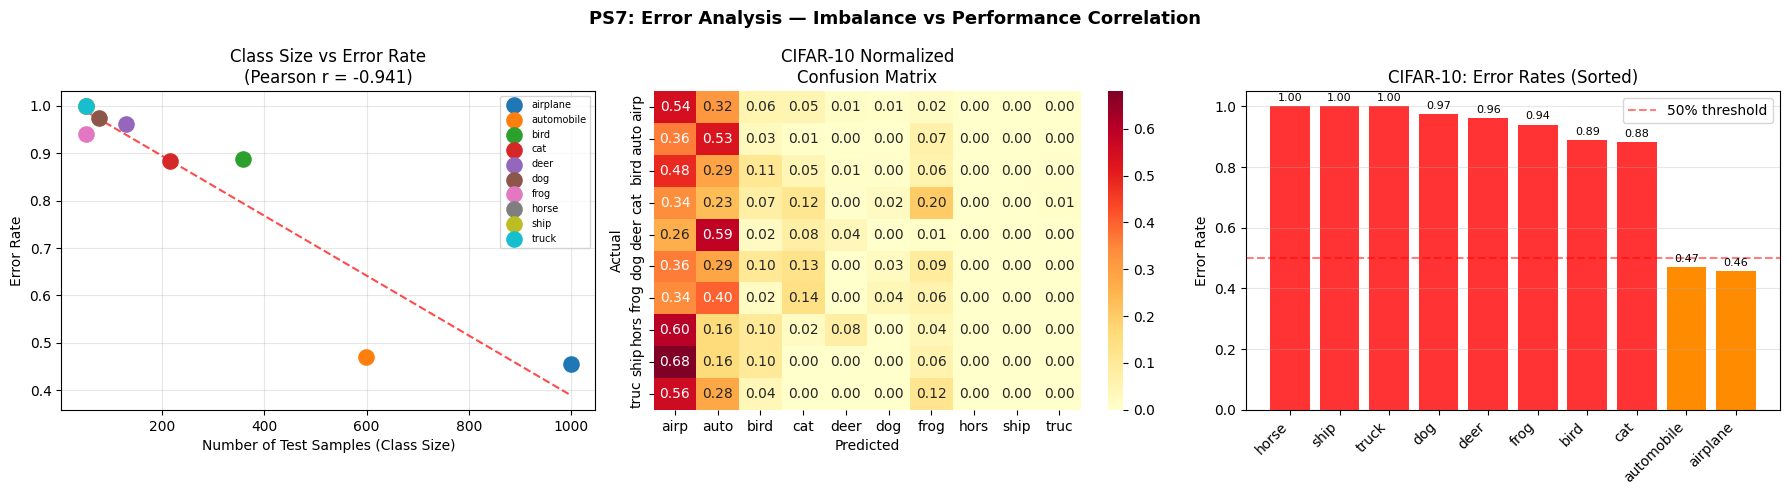

In [46]:
# ─── Correlation: Class Imbalance vs Error Rate ───
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('PS7: Error Analysis — Imbalance vs Performance Correlation', fontsize=13, fontweight='bold')

# 1: CIFAR-10 error rate vs class count
class_counts_test = [np.sum(y_cifar_test == c) for c in range(NUM_CIFAR)]
error_rates = [class_errors[CIFAR_CLASSES[c]]['error_rate'] for c in range(NUM_CIFAR)]
colors_scatter = plt.cm.tab10(np.arange(NUM_CIFAR)/NUM_CIFAR)
ax = axes[0]
for c in range(NUM_CIFAR):
    ax.scatter(class_counts_test[c], error_rates[c], color=colors_scatter[c],
               s=120, label=CIFAR_CLASSES[c], zorder=5)
corr = np.corrcoef(class_counts_test, error_rates)[0,1]
ax.set_xlabel('Number of Test Samples (Class Size)')
ax.set_ylabel('Error Rate')
ax.set_title(f'Class Size vs Error Rate\n(Pearson r = {corr:.3f})')
ax.legend(fontsize=7, loc='upper right', markerscale=1)
ax.grid(True, alpha=0.3)
# Trend line
z = np.polyfit(class_counts_test, error_rates, 1)
p = np.poly1d(z)
xs = np.linspace(min(class_counts_test), max(class_counts_test), 50)
ax.plot(xs, p(xs), 'r--', alpha=0.7, label='Trend')

# 2: Normalized confusion matrix (CIFAR-10)
ax = axes[1]
cm_norm = cm_cifar.astype('float') / cm_cifar.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=ax,
            xticklabels=[c[:4] for c in CIFAR_CLASSES],
            yticklabels=[c[:4] for c in CIFAR_CLASSES],
            cmap='YlOrRd', cbar=True)
ax.set_title('CIFAR-10 Normalized\nConfusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# 3: Error rate bar chart (most problematic classes first)
ax = axes[2]
sorted_classes = sorted(range(NUM_CIFAR), key=lambda c: class_errors[CIFAR_CLASSES[c]]['error_rate'], reverse=True)
sorted_names   = [CIFAR_CLASSES[c] for c in sorted_classes]
sorted_rates   = [class_errors[CIFAR_CLASSES[c]]['error_rate'] for c in sorted_classes]
sorted_colors  = ['#FF3333' if r > 0.5 else '#FF8C00' if r > 0.3 else '#4CAF50' for r in sorted_rates]
bars = ax.bar(sorted_names, sorted_rates, color=sorted_colors)
ax.set_title('CIFAR-10: Error Rates (Sorted)')
ax.set_xticklabels(sorted_names, rotation=45, ha='right')
ax.set_ylabel('Error Rate')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, rate in zip(bars, sorted_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
            f'{rate:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('ps7_error_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
